# 🫀 Projet Final ML & Deep Learning
## Prédiction de Maladies Cardiaques — Dataset Heart Disease (UCI)

**Auteur :** [Votre Nom]  
**Dataset :** Heart Disease UCI — Cleveland  
**Problème :** Classification binaire (présence ou absence de maladie cardiaque)

---
### Structure du notebook
1. Présentation du problème & chargement des données
2. Analyse Exploratoire (EDA)
3. Feature Engineering & Preprocessing
4. Modèles ML — Entraînement & Comparaison
5. Hyperparameter Tuning
6. Explicabilité (SHAP)
7. Modèle Deep Learning (ANN)
8. Conclusion & Limites

In [80]:
# ============================================================
# IMPORTS GLOBAUX
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Explainability
import shap

# Config graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('✅ Imports OK | TF version:', tf.__version__)

✅ Imports OK | TF version: 2.21.0


---
## PARTIE 1 — Présentation du Problème & Chargement des Données

### Contexte
Les maladies cardiovasculaires sont la première cause de mortalité mondiale (OMS). Ce projet vise à **prédire la présence d'une maladie cardiaque** à partir de données cliniques et biologiques de patients.

### Dataset — Heart Disease UCI (Cleveland)
- **Source :** UCI Machine Learning Repository
- **Observations :** 303 patients
- **Features :** 13 variables cliniques
- **Cible :** `target` — 0 = absence, 1 = présence de maladie cardiaque

| Feature | Description |
|---------|-------------|
| age | Âge du patient |
| sex | Sexe (1=M, 0=F) |
| cp | Type de douleur thoracique (0–3) |
| trestbps | Pression artérielle au repos (mmHg) |
| chol | Cholestérol sérique (mg/dl) |
| fbs | Glycémie à jeun > 120 mg/dl (1=oui) |
| restecg | Résultats ECG au repos (0–2) |
| thalach | Fréquence cardiaque maximale |
| exang | Angine induite par l'effort (1=oui) |
| oldpeak | Dépression ST induite par l'effort |
| slope | Pente du segment ST |
| ca | Nombre de vaisseaux colorés (0–3) |
| thal | Thalassémie (0=normal, 1=fixed, 2=reversable) |

In [81]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

# Option 1 : Chargement depuis UCI directement
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"

try:
    df = pd.read_csv(url)
    print("✅ Dataset chargé depuis URL")
except:
    # Option 2 : Chargement depuis sklearn
    from sklearn.datasets import fetch_openml
    data = fetch_openml('heart-statlog', version=1, as_frame=True)
    df = data.frame
    df.rename(columns={'class': 'target'}, inplace=True)
    df['target'] = (df['target'] == 'present').astype(int)
    print("✅ Dataset chargé depuis sklearn OpenML")

# Nettoyage des noms de colonnes (uniformisation)
if 'target' not in df.columns:
    df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
                  'thalach','exang','oldpeak','slope','ca','thal','target']

print(f"\n📊 Dimensions : {df.shape}")
print(f"📋 Colonnes   : {list(df.columns)}")
df.head()

✅ Dataset chargé depuis URL

📊 Dimensions : (303, 14)
📋 Colonnes   : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [82]:
# Aperçu statistique
print("=== TYPES DES VARIABLES ===")
print(df.dtypes)
print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe().round(2)

=== TYPES DES VARIABLES ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

=== STATISTIQUES DESCRIPTIVES ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [83]:
# Valeurs manquantes
missing = df.isnull().sum()
print("=== VALEURS MANQUANTES ===")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Aucune valeur manquante")

# Distribution de la cible
print("\n=== DISTRIBUTION DE LA CIBLE ===")
print(df['target'].value_counts())
print(f"\nRépartition : {df['target'].value_counts(normalize=True).round(3).to_dict()}")

=== VALEURS MANQUANTES ===
✅ Aucune valeur manquante

=== DISTRIBUTION DE LA CIBLE ===
target
1    165
0    138
Name: count, dtype: int64

Répartition : {1: 0.545, 0: 0.455}


---
## PARTIE 2 — Analyse Exploratoire (EDA)

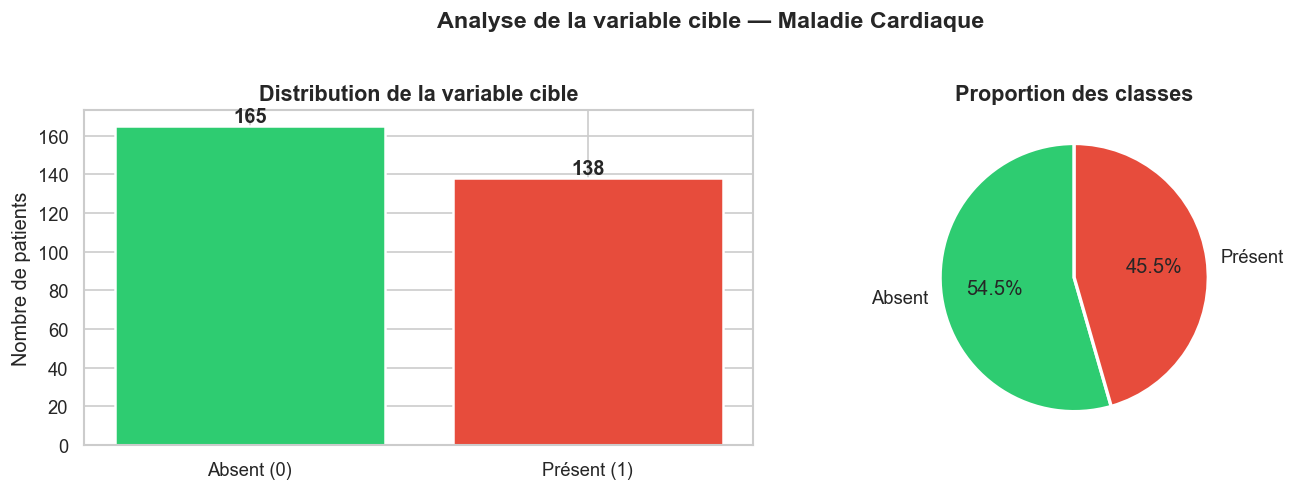

➡️  Données relativement équilibrées — pas besoin d'oversampling.


In [ ]:
# ============================================================
# 2.1 Distribution de la variable cible
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()
axes[0].bar(['Absent (0)', 'Présent (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de la variable cible', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Absent', 'Présent'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.suptitle('Analyse de la variable cible — Maladie Cardiaque', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('fig_target_distribution.png', bbox_inches='tight')
plt.show()
print("➡️  Données relativement équilibrées — pas besoin d'oversampling.")

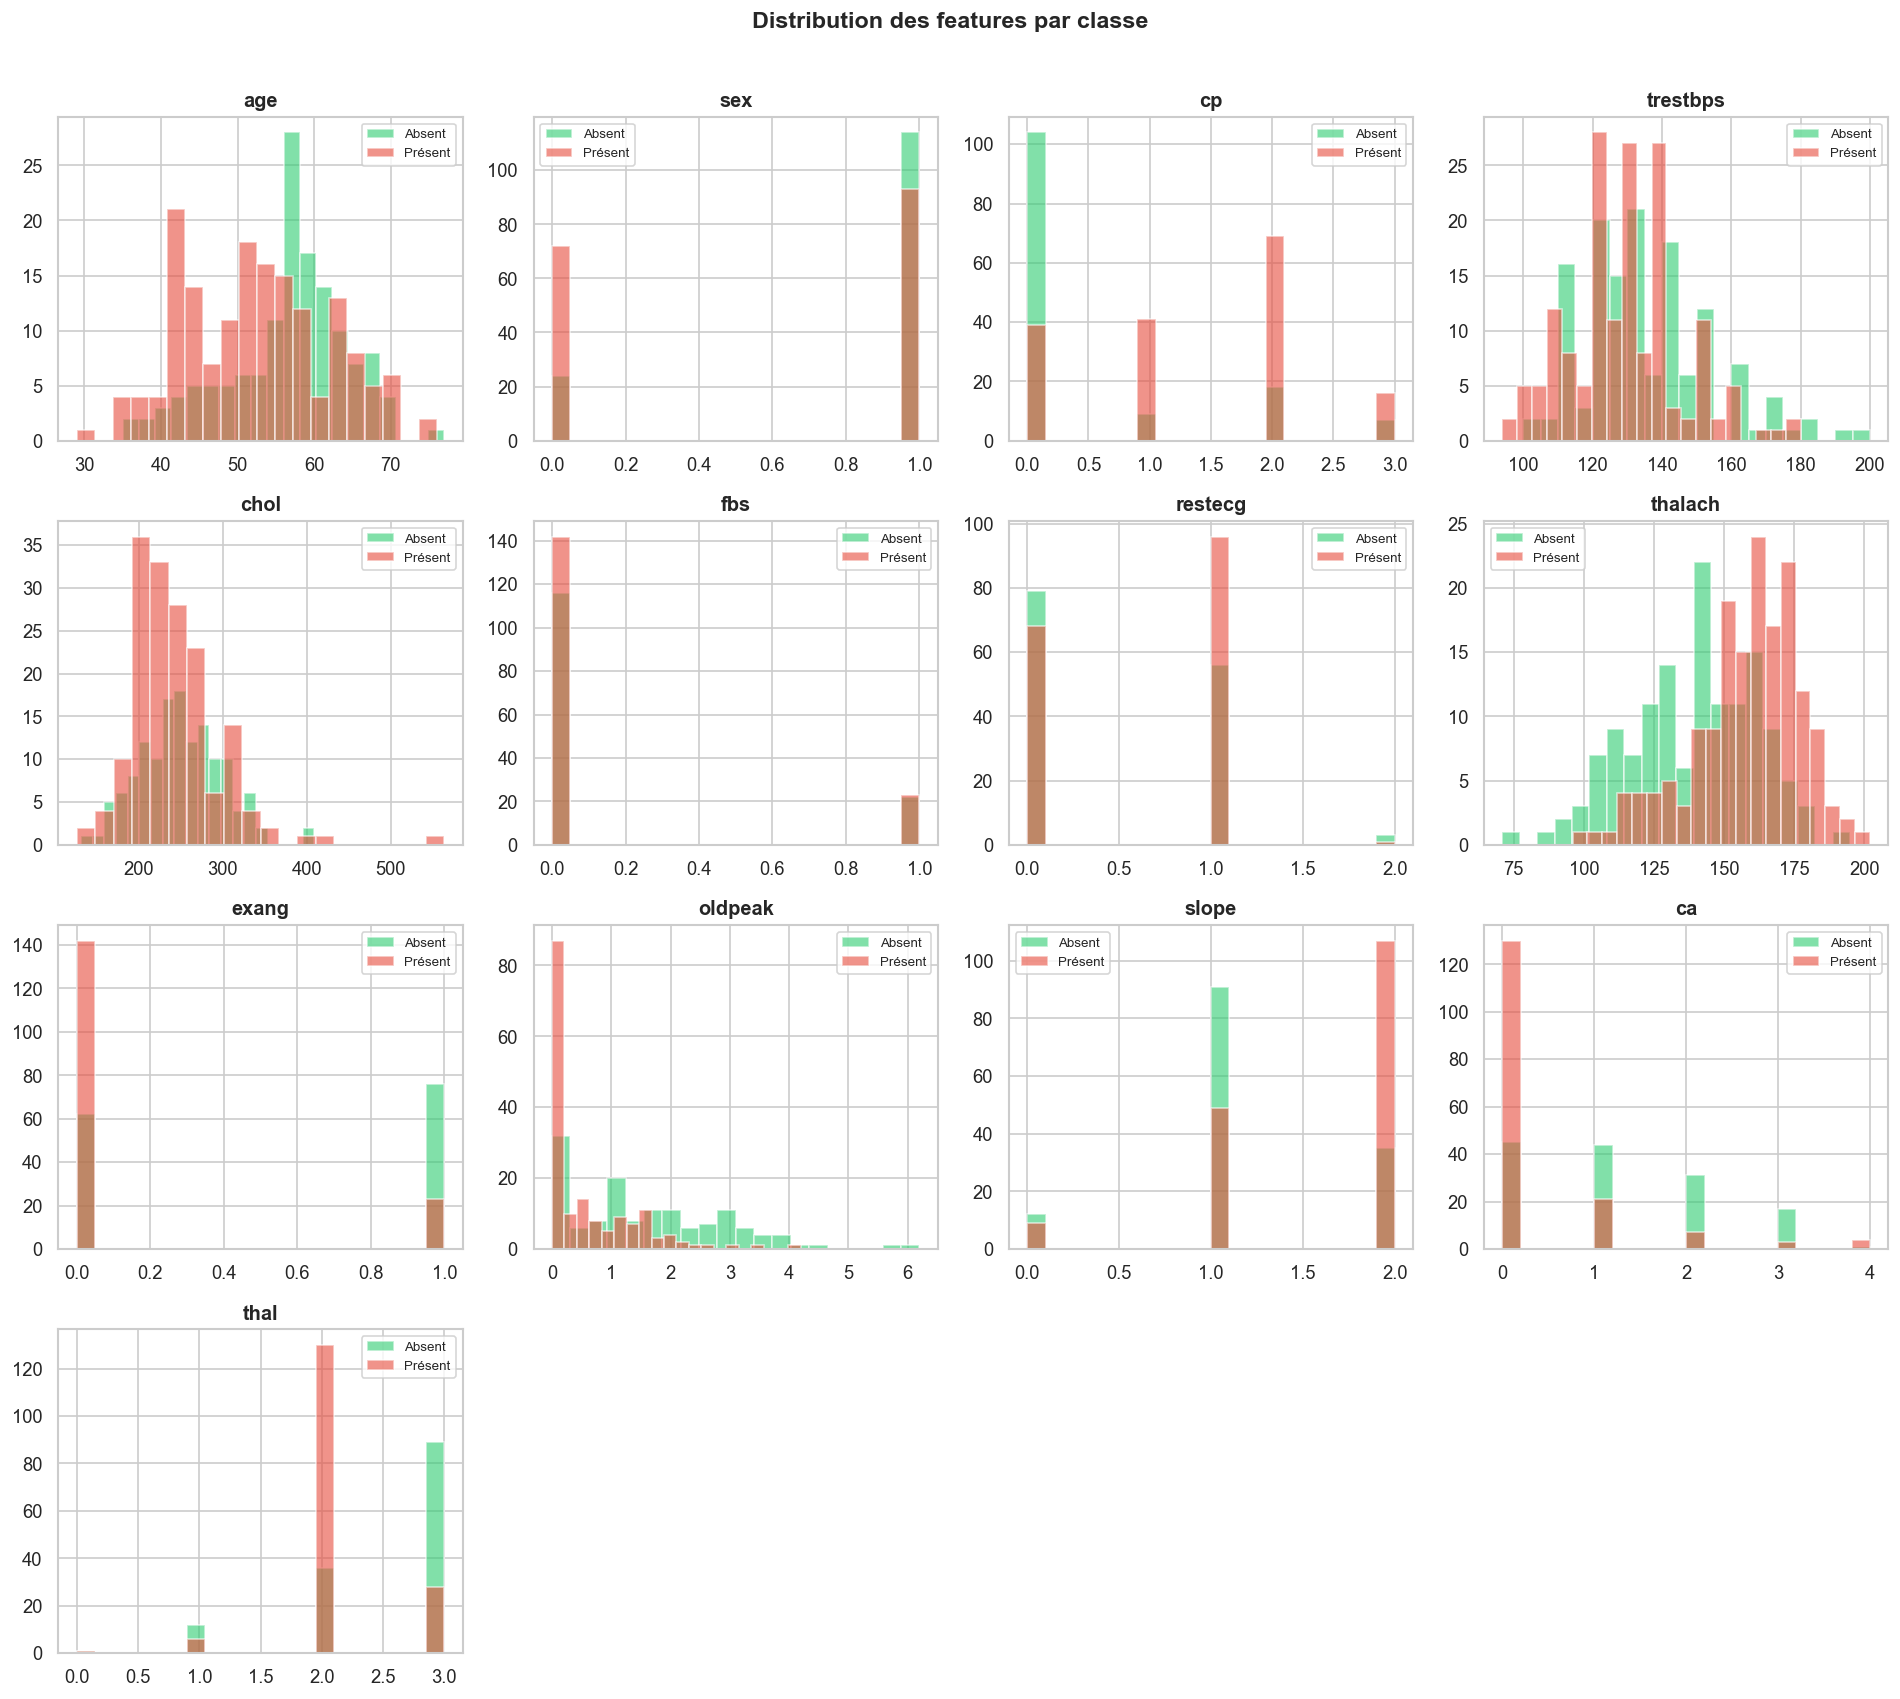

In [ ]:
# ============================================================
# 2.2 Distribution de toutes les features
# ============================================================
features = [c for c in df.columns if c != 'target']
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color, name in [(0, '#2ecc71', 'Absent'), (1, '#e74c3c', 'Présent')]:
        axes[i].hist(df[df['target'] == label][feat], bins=20,
                     alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features par classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('fig_features_distributions.png', bbox_inches='tight')
plt.show()

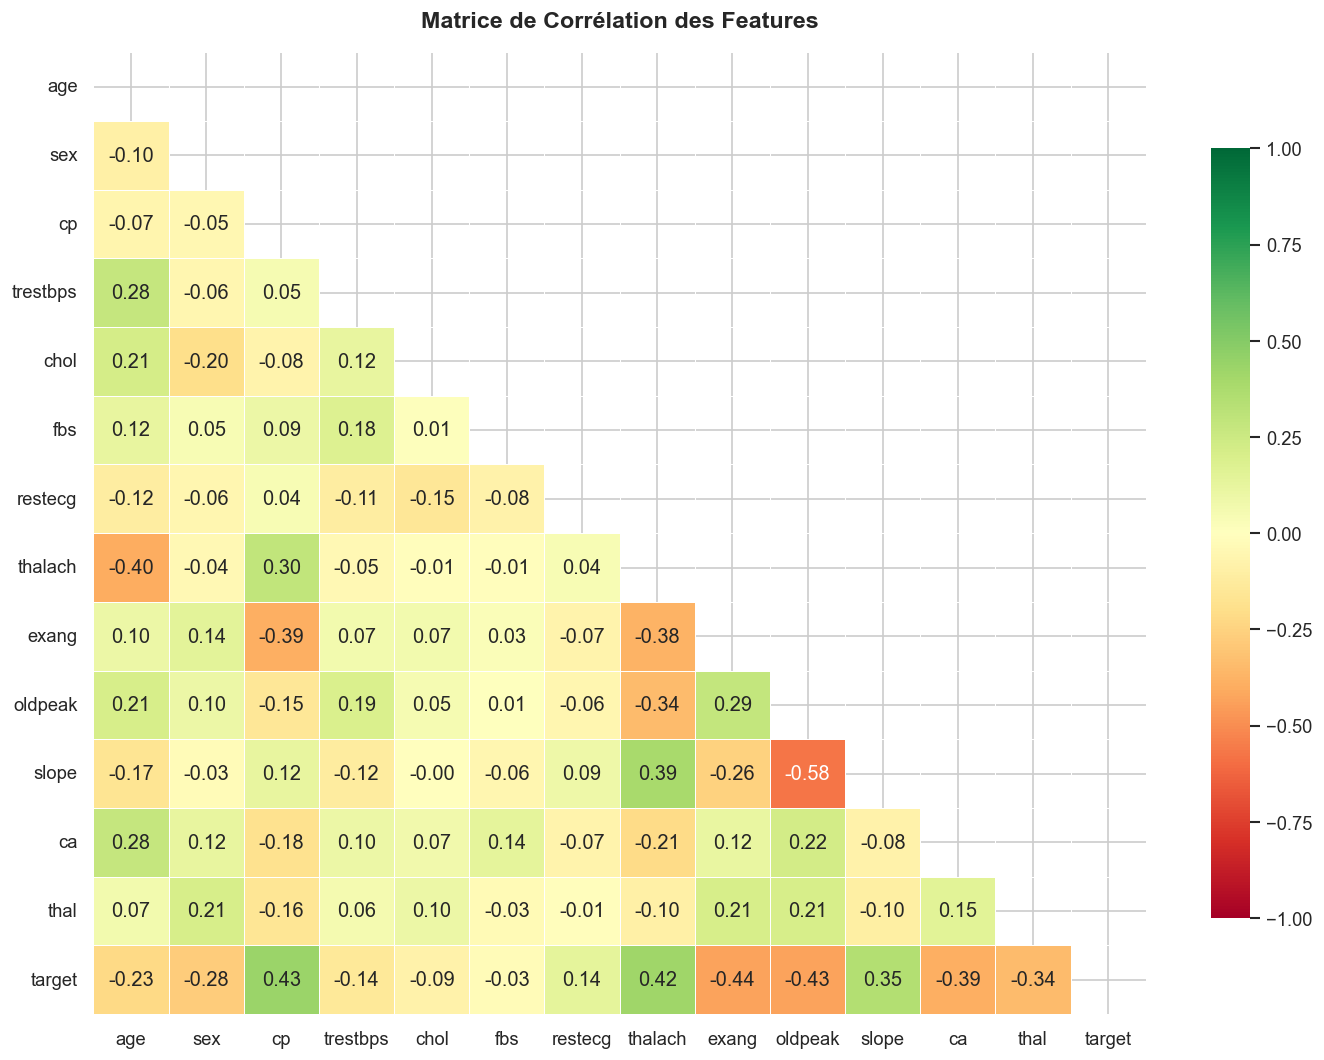

Corrélations les plus fortes avec 'target':
exang      0.436757
cp         0.433798
oldpeak    0.430696
thalach    0.421741
ca         0.391724
slope      0.345877
thal       0.344029
sex        0.280937
Name: target, dtype: float64


In [ ]:
# ============================================================
# 2.3 Matrice de corrélation
# ============================================================
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation des Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
# plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()
print("Corrélations les plus fortes avec 'target':")
print(corr_matrix['target'].drop('target').abs().sort_values(ascending=False).head(8))

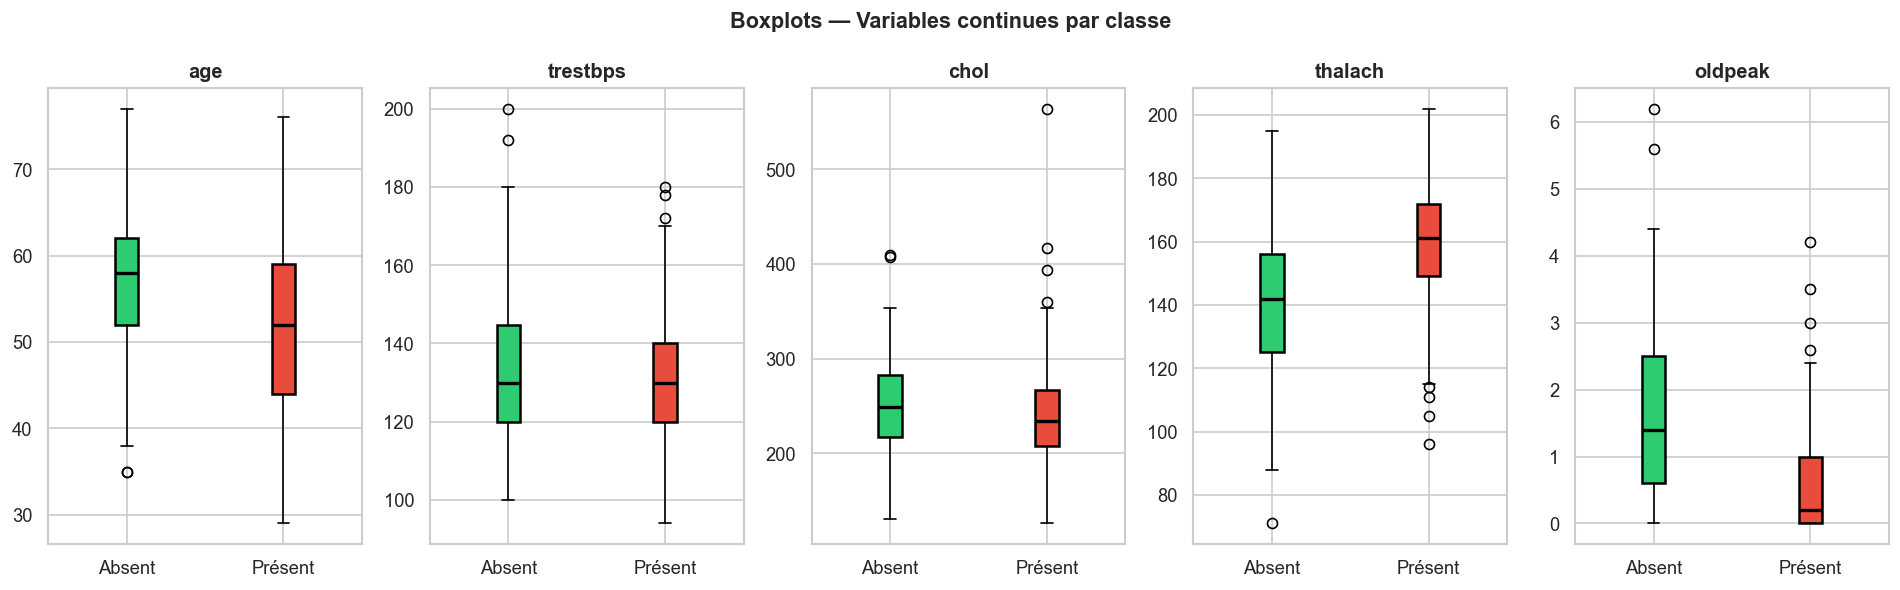

➡️  Observations : thalach (fréquence cardiaque) et oldpeak semblent très discriminants.


In [ ]:
# ============================================================
# 2.4 Analyse des outliers avec boxplots
# ============================================================
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(numerical_features), figsize=(16, 5))
for i, feat in enumerate(numerical_features):
    data_0 = df[df['target'] == 0][feat]
    data_1 = df[df['target'] == 1][feat]
    bp = axes[i].boxplot([data_0, data_1],
                          labels=['Absent', 'Présent'],
                          patch_artist=True,
                          boxprops=dict(linewidth=1.5),
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_title(feat, fontweight='bold')

plt.suptitle('Boxplots — Variables continues par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()
print("➡️  Observations : thalach (fréquence cardiaque) et oldpeak semblent très discriminants.")

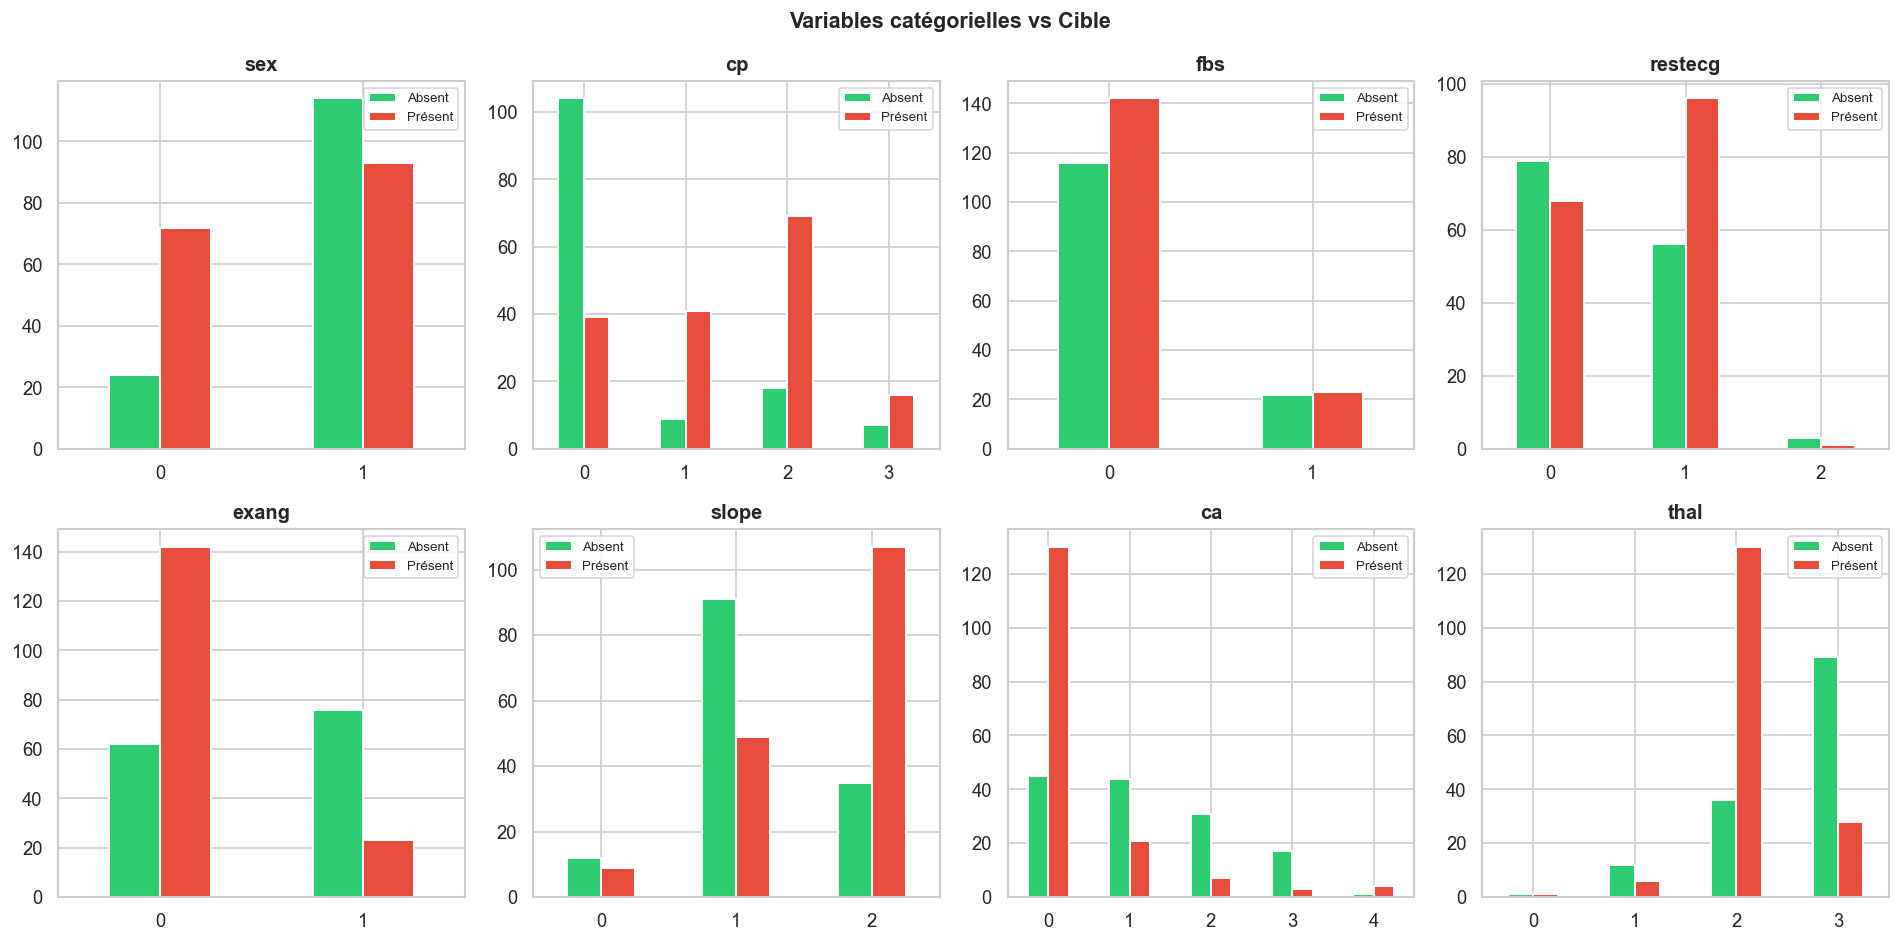

In [ ]:
# ============================================================
# 2.5 Analyse des variables catégorielles
# ============================================================
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = df.groupby([feat, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Absent', 'Présent'], fontsize=8)

plt.suptitle('Variables catégorielles vs Cible', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_categorical.png', bbox_inches='tight')
plt.show()

---
## PARTIE 3 — Feature Engineering & Preprocessing

### Approche retenue
1. **Gestion des valeurs aberrantes** (capping IQR)
2. **Création de nouvelles features** (interactions cliniques pertinentes)
3. **Encodage** des variables catégorielles (OneHot)
4. **Sélection de features** par importance statistique et modèle
5. **Standardisation** pour les modèles sensibles à l'échelle

In [89]:
# ============================================================
# 3.1 Copie de travail & gestion des valeurs aberrantes
# ============================================================
df_clean = df.copy()

def cap_outliers_iqr(df, columns, factor=1.5):
    """Écrêtage des outliers par méthode IQR."""
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        if n_outliers > 0:
            print(f"  {col}: {n_outliers} outliers écrêtés [{lower:.1f}, {upper:.1f}]")
    return df

print("=== Gestion des outliers (IQR) ===")
df_clean = cap_outliers_iqr(df_clean, ['trestbps', 'chol', 'oldpeak'])
print("\n✅ Outliers traités")

=== Gestion des outliers (IQR) ===
  trestbps: 9 outliers écrêtés [90.0, 170.0]
  chol: 5 outliers écrêtés [115.8, 369.8]
  oldpeak: 5 outliers écrêtés [-2.4, 4.0]

✅ Outliers traités


In [90]:
# ============================================================
# 3.2 Feature Engineering — Création de nouvelles variables
# ============================================================

# Feature 1 : Ratio fréquence cardiaque / âge
# Interprétation clinique : réserve cardiaque normalisée par l'âge
df_clean['hr_age_ratio'] = df_clean['thalach'] / df_clean['age']

# Feature 2 : Risque cardiovasculaire composé
# Combinaison de facteurs de risque connus (HTA + cholestérol + âge)
df_clean['cardio_risk_score'] = (
    (df_clean['trestbps'] / 120) * 
    (df_clean['chol'] / 200) * 
    (df_clean['age'] / 60)
)

# Feature 3 : Stress cardiaque (dépression ST × présence d'angine d'effort)
df_clean['exang_oldpeak'] = df_clean['exang'] * df_clean['oldpeak']

# Feature 4 : Hommes > 50 ans (groupe à risque élevé selon littérature médicale)
df_clean['high_risk_male'] = ((df_clean['sex'] == 1) & (df_clean['age'] > 50)).astype(int)

# Feature 5 : Type de douleur thoracique asymptomatique (cp=0 = le plus risqué)
df_clean['asymptomatic_cp'] = (df_clean['cp'] == 0).astype(int)

print("=== Nouvelles features créées ===")
new_features = ['hr_age_ratio', 'cardio_risk_score', 'exang_oldpeak', 'high_risk_male', 'asymptomatic_cp']
print(df_clean[new_features + ['target']].corr()['target'].sort_values(ascending=False))
print(f"\n✅ Dataset enrichi : {df_clean.shape[1]} features (avant encodage)")

=== Nouvelles features créées ===
target               1.000000
hr_age_ratio         0.382753
cardio_risk_score   -0.213341
high_risk_male      -0.301804
exang_oldpeak       -0.446695
asymptomatic_cp     -0.516015
Name: target, dtype: float64

✅ Dataset enrichi : 19 features (avant encodage)


In [91]:
# ============================================================
# 3.3 Encodage One-Hot des variables catégorielles
# ============================================================

# Variables avec plus de 2 catégories → OneHot
cat_to_encode = ['cp', 'restecg', 'slope', 'thal']

# Forcer le type int (évite les problèmes avec float)
for col in cat_to_encode:
    df_clean[col] = df_clean[col].astype(int)

df_encoded = pd.get_dummies(df_clean, columns=cat_to_encode, drop_first=False)
print(f"Dimensions après encodage : {df_encoded.shape}")
print(f"Nouvelles colonnes : {[c for c in df_encoded.columns if c not in df_clean.columns]}")

Dimensions après encodage : (303, 29)
Nouvelles colonnes : ['cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


In [92]:
# ============================================================
# 3.4 Séparation X / y et train/test split
# ============================================================
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train : {X_train.shape[0]} exemples | Test : {X_test.shape[0]} exemples")
print(f"Équilibre train → {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Équilibre test  → {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train : 242 exemples | Test : 61 exemples
Équilibre train → {1: 0.545, 0: 0.455}
Équilibre test  → {1: 0.541, 0: 0.459}


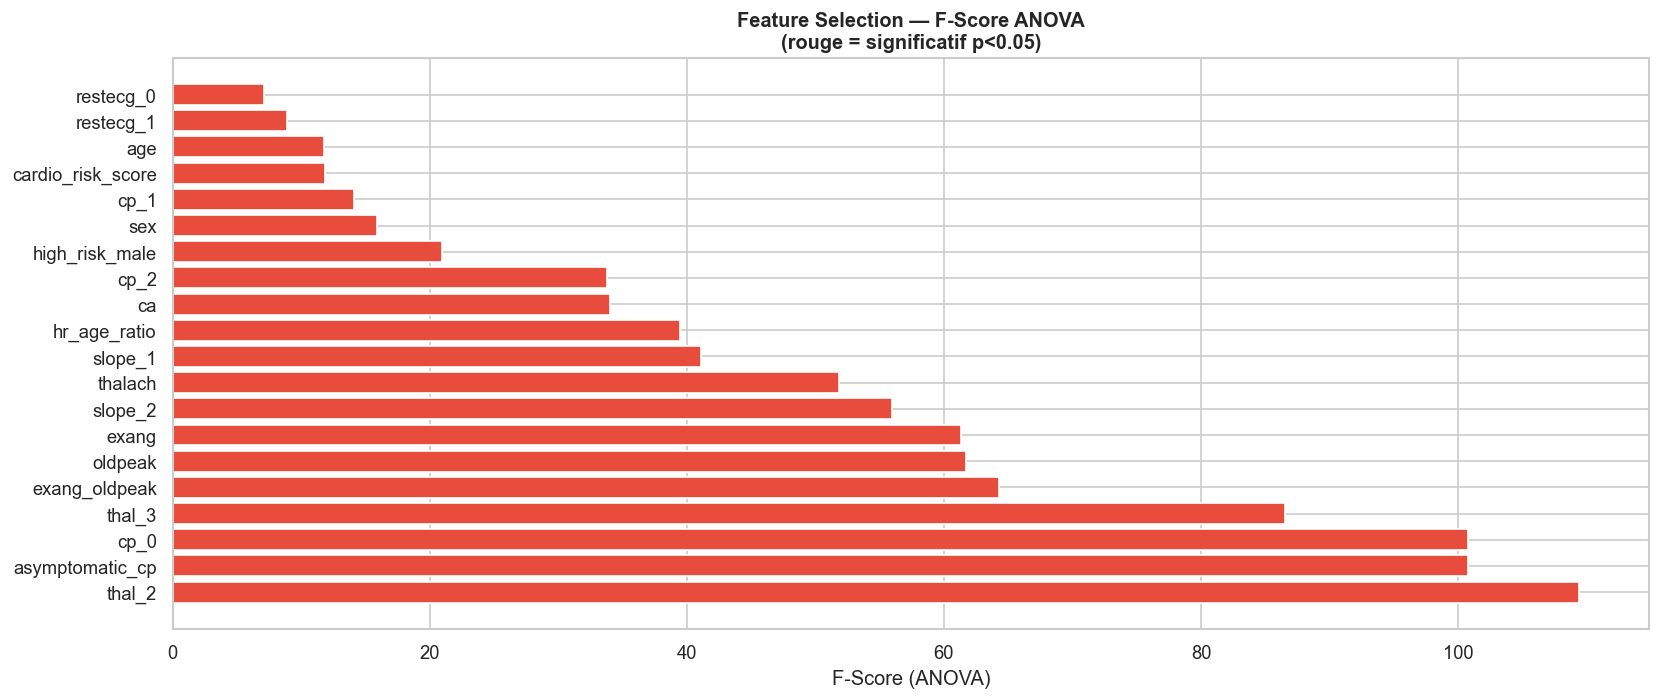


✅ 23 features retenues sur 28 : ['thal_2', 'asymptomatic_cp', 'cp_0', 'thal_3', 'exang_oldpeak', 'oldpeak', 'exang', 'slope_2', 'thalach', 'slope_1', 'hr_age_ratio', 'ca', 'cp_2', 'high_risk_male', 'sex', 'cp_1', 'cardio_risk_score', 'age', 'restecg_1', 'restecg_0', 'chol', 'thal_1', 'trestbps']


In [ ]:
# ============================================================
# 3.5 Feature Selection — Méthode statistique (f_classif)
# ============================================================
scaler_tmp = StandardScaler()
X_scaled_tmp = scaler_tmp.fit_transform(X_train)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled_tmp, y_train)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in feature_scores['p_value']]
ax.barh(feature_scores['feature'][:20], feature_scores['f_score'][:20], color=colors[:20])
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title('Feature Selection — F-Score ANOVA\n(rouge = significatif p<0.05)', fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_feature_selection.png', bbox_inches='tight')
plt.show()

# Sélection des features significatives
selected_features = feature_scores[feature_scores['p_value'] < 0.05]['feature'].tolist()
print(f"\n✅ {len(selected_features)} features retenues sur {len(X.columns)} : {selected_features}")

In [94]:
# ============================================================
# 3.6 Préparation finale des jeux de données
# ============================================================

# On garde toutes les features (pour les modèles basés arbres)
# Et un sous-ensemble sélectionné (pour LR, KNN, SVM)
X_train_all = X_train.copy()
X_test_all = X_test.copy()

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

# Scaler global
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

X_train_sel_scaled = StandardScaler().fit_transform(X_train_sel)
X_test_sel_scaled = StandardScaler().fit(X_train_sel).transform(X_test_sel)

print("✅ Données prêtes pour la modélisation")
print(f"   → X_train complet     : {X_train_scaled.shape}")
print(f"   → X_train sélectionné : {X_train_sel_scaled.shape}")

✅ Données prêtes pour la modélisation
   → X_train complet     : (242, 28)
   → X_train sélectionné : (242, 23)


---
## PARTIE 4 — Modèles ML — Entraînement & Comparaison

Stratégie d'évaluation : **Stratified K-Fold (k=5)** sur le train set, puis évaluation finale sur le test set.

Métriques retenues : **Accuracy, F1-score, ROC-AUC** (F1 et AUC sont plus robustes que l'accuracy seule).

In [95]:
# ============================================================
# 4.0 Fonction d'évaluation commune
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Entraîne et évalue un modèle. Retourne un dict de métriques."""
    # Cross-validation
    cv_acc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc')
    
    # Entraînement final sur tout le train set
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model'     : name,
        'CV_Acc'    : cv_acc.mean(),
        'CV_Acc_std': cv_acc.std(),
        'CV_F1'     : cv_f1.mean(),
        'CV_AUC'    : cv_auc.mean(),
        'Test_Acc'  : accuracy_score(y_te, y_pred),
        'Test_F1'   : f1_score(y_te, y_pred),
        'Test_AUC'  : roc_auc_score(y_te, y_prob) if y_prob is not None else None,
        'model_obj' : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
    }
    print(f"[{name:<20}] Test Acc: {metrics['Test_Acc']:.3f} | F1: {metrics['Test_F1']:.3f} | AUC: {metrics['Test_AUC']:.3f} | CV_Acc: {cv_acc.mean():.3f}±{cv_acc.std():.3f}")
    return metrics

print("=" * 90)
print(f"{'Modèle':<22} {'Test Acc':>10} {'F1':>8} {'AUC':>8} {'CV_Acc':>18}")
print("=" * 90)

Modèle                   Test Acc       F1      AUC             CV_Acc


In [96]:
# ============================================================
# 4.1 Régression Logistique
# ============================================================
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results['LR'] = evaluate_model('Logistic Regression', lr,
                                X_train_scaled, X_test_scaled, y_train, y_test)

[Logistic Regression ] Test Acc: 0.836 | F1: 0.857 | AUC: 0.882 | CV_Acc: 0.793±0.074


Meilleur k = 13


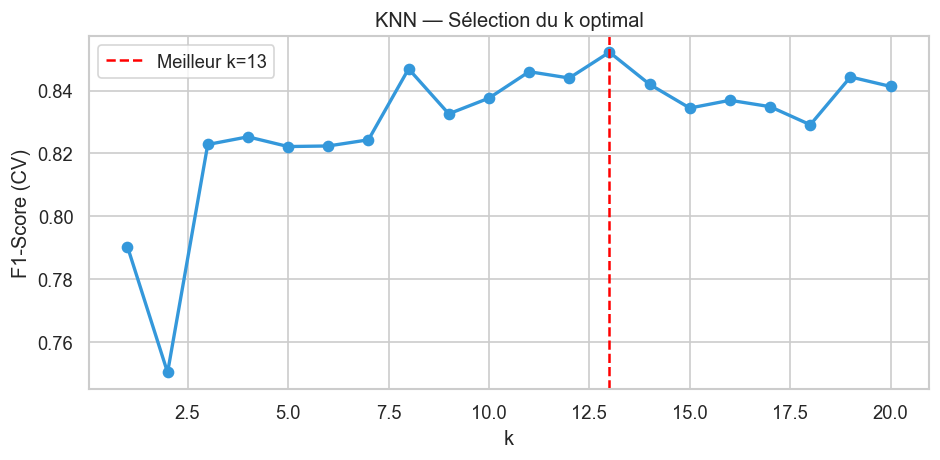

[KNN                 ] Test Acc: 0.836 | F1: 0.857 | AUC: 0.892 | CV_Acc: 0.835±0.072


In [ ]:
# ============================================================
# 4.2 K-Nearest Neighbors
# ============================================================
# Recherche du k optimal
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    k_scores.append((k, score))

best_k = max(k_scores, key=lambda x: x[1])[0]
print(f"Meilleur k = {best_k}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.plot([x[0] for x in k_scores], [x[1] for x in k_scores],
         marker='o', color='#3498db', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Meilleur k={best_k}')
plt.xlabel('k')
plt.ylabel('F1-Score (CV)')
plt.title('KNN — Sélection du k optimal')
plt.legend()
plt.tight_layout()
# plt.savefig('fig_knn_k_selection.png', bbox_inches='tight')
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
results['KNN'] = evaluate_model('KNN', knn,
                                 X_train_scaled, X_test_scaled, y_train, y_test)

[Decision Tree       ] Test Acc: 0.623 | F1: 0.685 | AUC: 0.653 | CV_Acc: 0.727±0.068


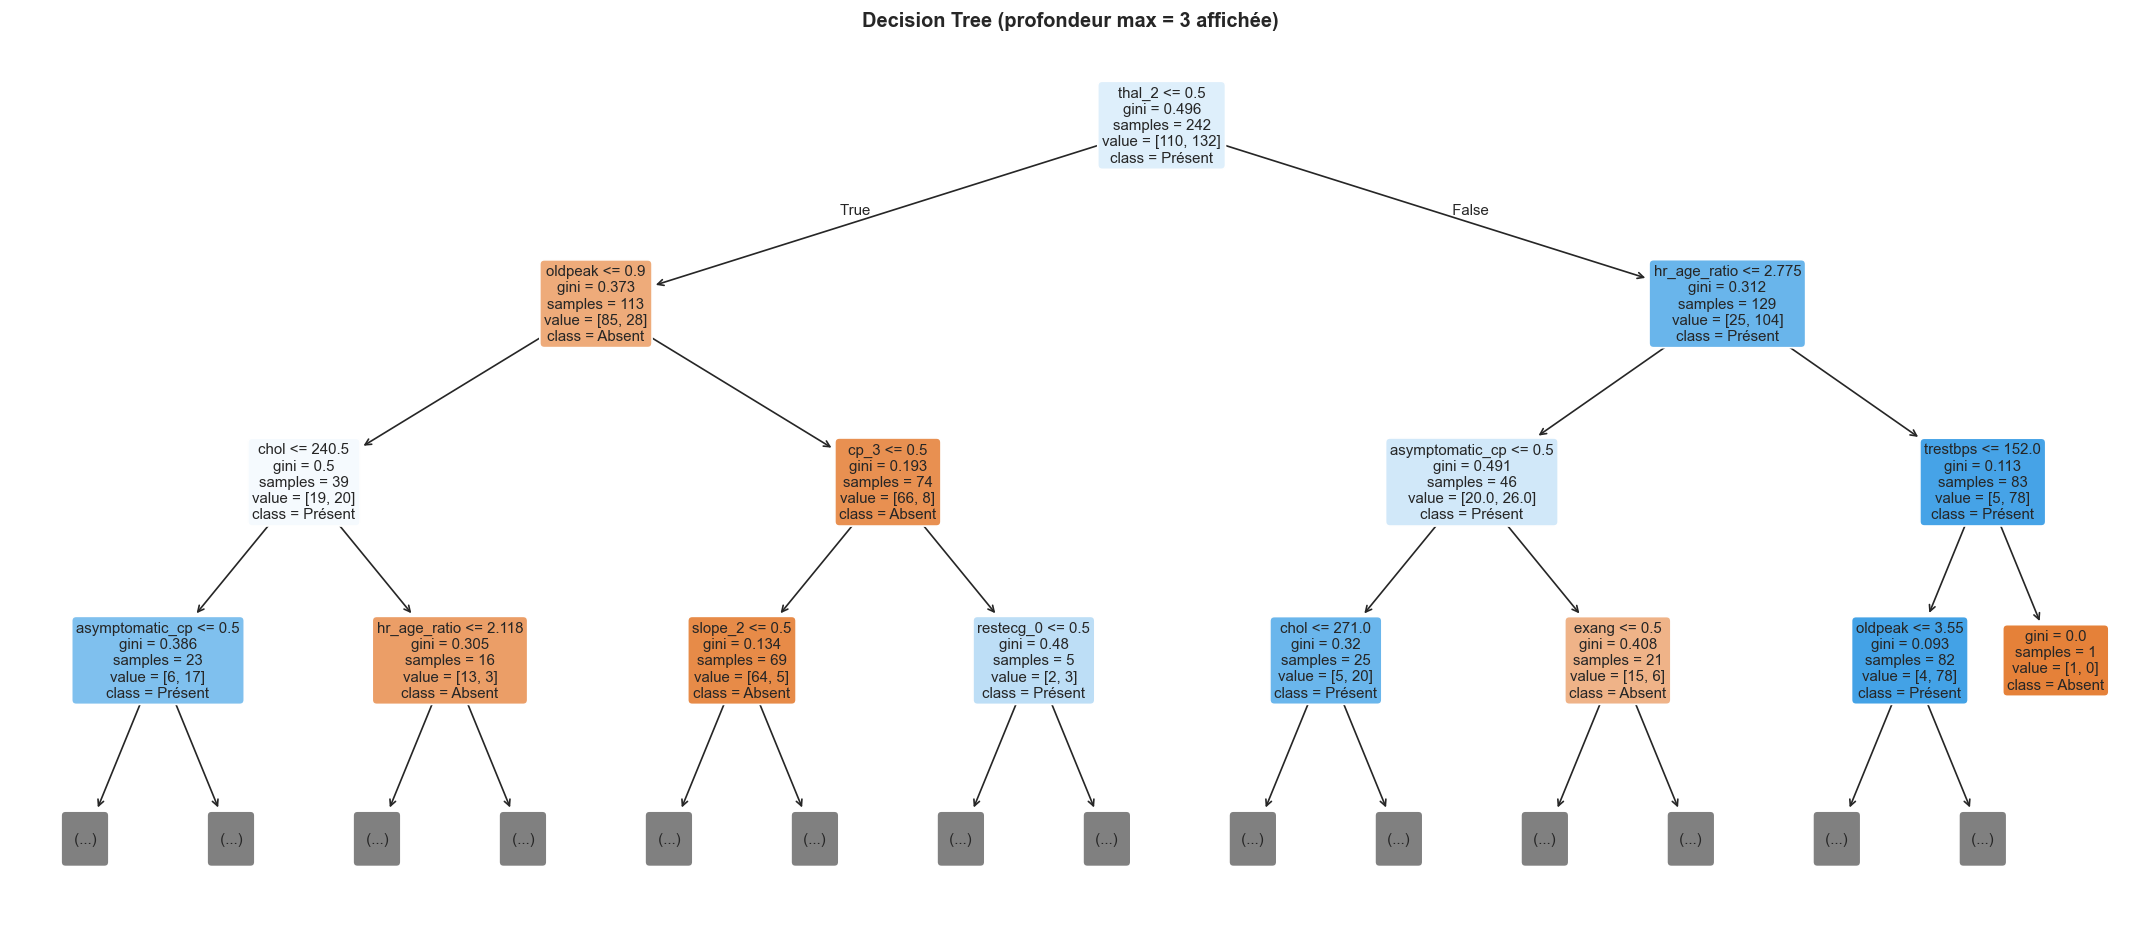

In [ ]:
# ============================================================
# 4.3 Decision Tree
# ============================================================
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
results['DT'] = evaluate_model('Decision Tree', dt,
                                X_train_all.values, X_test_all.values, y_train, y_test)

# Visualisation de l'arbre
from sklearn.tree import plot_tree
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=list(X_train_all.columns), class_names=['Absent', 'Présent'],
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title('Decision Tree (profondeur max = 3 affichée)', fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_decision_tree.png', bbox_inches='tight')
plt.show()

[Random Forest       ] Test Acc: 0.787 | F1: 0.822 | AUC: 0.888 | CV_Acc: 0.801±0.072


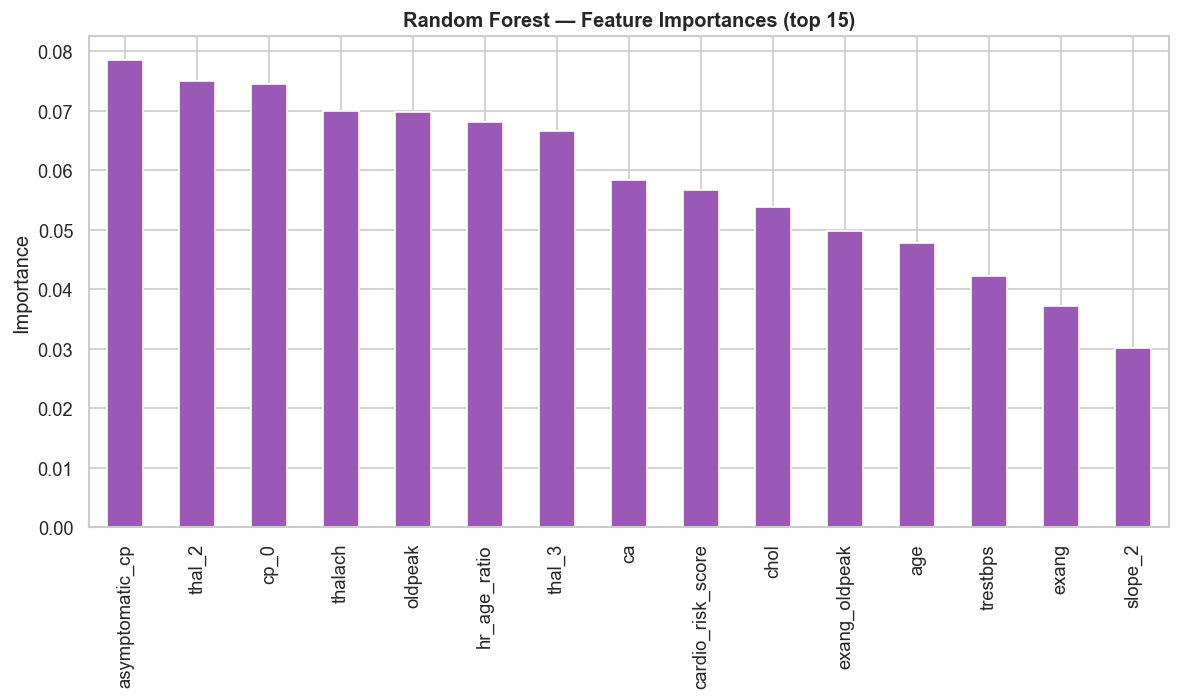

In [ ]:
# ============================================================
# 4.4 Random Forest
# ============================================================
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
results['RF'] = evaluate_model('Random Forest', rf,
                                X_train_all.values, X_test_all.values, y_train, y_test)

# Feature importance RF
importances = pd.Series(rf.feature_importances_, index=X_train_all.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar', color='#9b59b6', edgecolor='white')
plt.title('Random Forest — Feature Importances (top 15)', fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
# plt.savefig('fig_rf_importance.png', bbox_inches='tight')
plt.show()

In [100]:
# ============================================================
# 4.5 Support Vector Machine
# ============================================================
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
results['SVM'] = evaluate_model('SVM (RBF)', svm,
                                 X_train_scaled, X_test_scaled, y_train, y_test)

[SVM (RBF)           ] Test Acc: 0.803 | F1: 0.833 | AUC: 0.878 | CV_Acc: 0.806±0.059


In [101]:
# ============================================================
# 4.6 Tableau comparatif & visualisations
# ============================================================
results_df = pd.DataFrame([
    {
        'Modèle': v['Model'],
        'CV Accuracy': f"{v['CV_Acc']:.3f} ± {v['CV_Acc_std']:.3f}",
        'Test Accuracy': round(v['Test_Acc'], 3),
        'Test F1': round(v['Test_F1'], 3),
        'Test AUC': round(v['Test_AUC'], 3) if v['Test_AUC'] else '-'
    } for v in results.values()
])
print("\n=== TABLEAU COMPARATIF DES MODÈLES ===")
print(results_df.to_string(index=False))


=== TABLEAU COMPARATIF DES MODÈLES ===
             Modèle   CV Accuracy  Test Accuracy  Test F1  Test AUC
Logistic Regression 0.793 ± 0.074          0.836    0.857     0.882
                KNN 0.835 ± 0.072          0.836    0.857     0.892
      Decision Tree 0.727 ± 0.068          0.623    0.685     0.653
      Random Forest 0.801 ± 0.072          0.787    0.822     0.888
          SVM (RBF) 0.806 ± 0.059          0.803    0.833     0.878


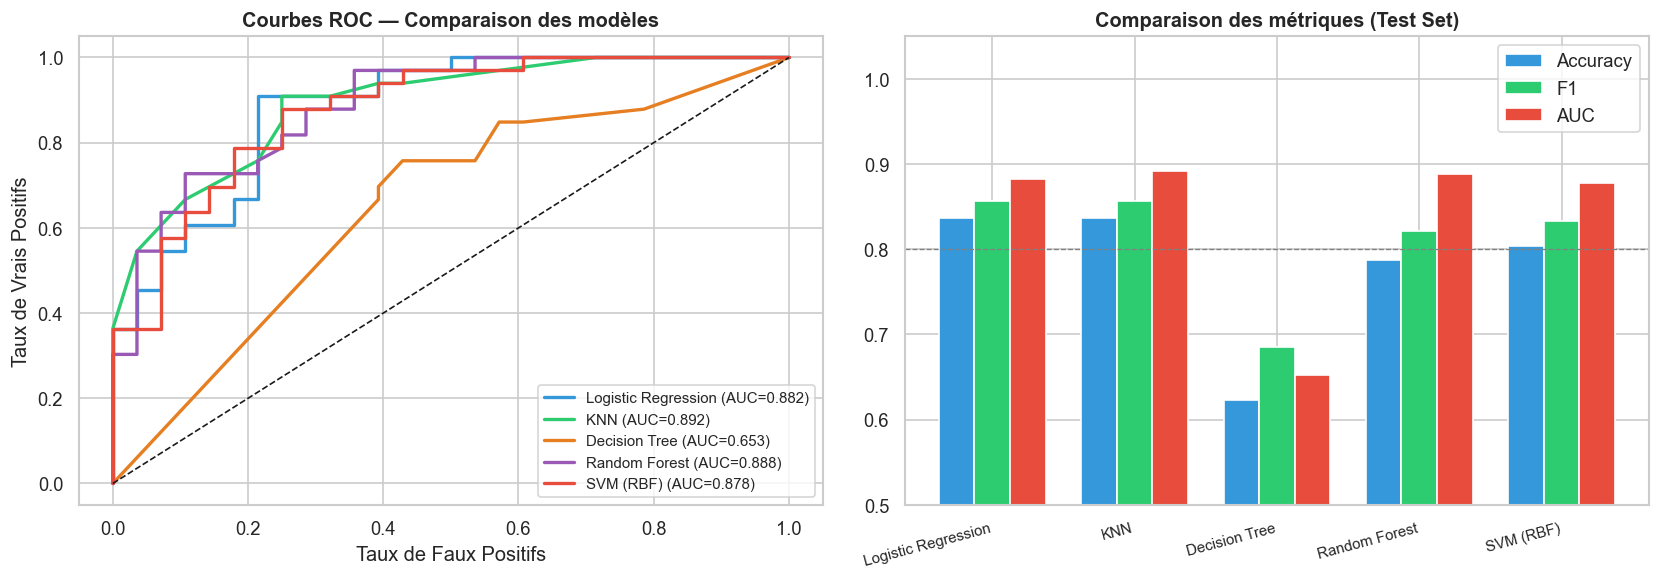

In [ ]:
# ============================================================
# 4.7 Courbes ROC comparatives
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
colors_roc = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
for (key, res), color in zip(results.items(), colors_roc):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        auc = res['Test_AUC']
        axes[0].plot(fpr, tpr, color=color, linewidth=2,
                     label=f"{res['Model']} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
axes[0].legend(fontsize=9)

# Barplot des métriques
models_names = [v['Model'] for v in results.values()]
test_acc = [v['Test_Acc'] for v in results.values()]
test_f1  = [v['Test_F1'] for v in results.values()]
test_auc = [v['Test_AUC'] for v in results.values()]

x = np.arange(len(models_names))
width = 0.25
axes[1].bar(x - width, test_acc, width, label='Accuracy', color='#3498db', edgecolor='white')
axes[1].bar(x, test_f1, width, label='F1', color='#2ecc71', edgecolor='white')
axes[1].bar(x + width, test_auc, width, label='AUC', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Comparaison des métriques (Test Set)', fontweight='bold')
axes[1].legend()
axes[1].axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, label='Seuil 0.8')

plt.tight_layout()
# plt.savefig('fig_roc_comparison.png', bbox_inches='tight')
plt.show()

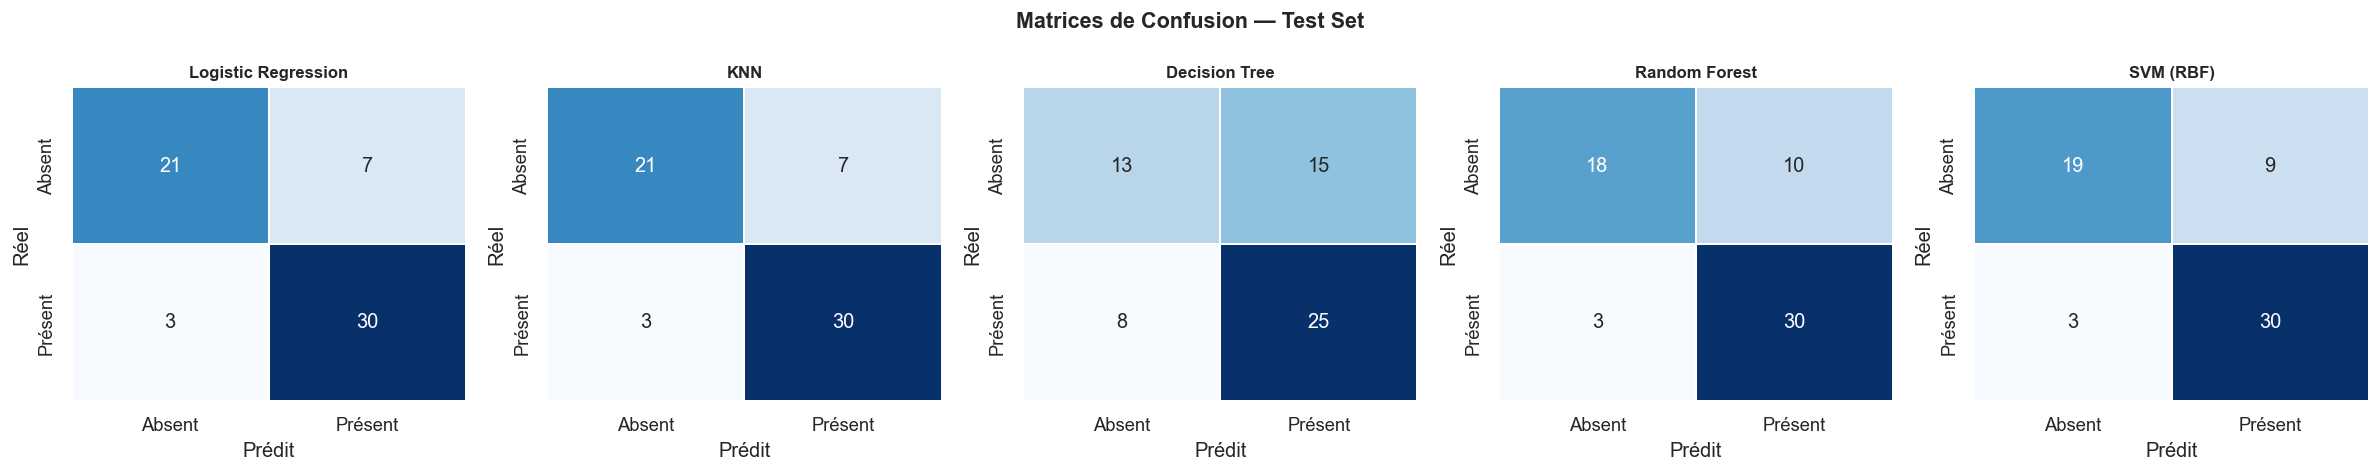


🏆 Meilleur modèle (AUC) : KNN — AUC = 0.8918


In [ ]:
# ============================================================
# 4.8 Matrices de confusion
# ============================================================
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Absent', 'Présent'],
                yticklabels=['Absent', 'Présent'],
                ax=ax, cbar=False, linewidths=1)
    ax.set_title(res['Model'], fontweight='bold', fontsize=10)
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.suptitle('Matrices de Confusion — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

# Meilleur modèle
best_key = max(results.keys(), key=lambda k: results[k]['Test_AUC'])
print(f"\n🏆 Meilleur modèle (AUC) : {results[best_key]['Model']} — AUC = {results[best_key]['Test_AUC']:.4f}")

---
## PARTIE 5 — Hyperparameter Tuning

On effectue le tuning sur deux modèles :
- **Random Forest** : GridSearchCV
- **SVM** : RandomizedSearchCV (espace plus large)

On compare les performances avant/après tuning.

In [104]:
# ============================================================
# 5.1 GridSearchCV — Random Forest
# ============================================================
print("=== GridSearchCV — Random Forest ===")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = GridSearchCV(
    rf_base, param_grid_rf, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_all.values, y_train)

print(f"\n✅ Meilleurs paramètres : {grid_rf.best_params_}")
print(f"   CV AUC (avant) : {results['RF']['CV_AUC']:.4f}")
print(f"   CV AUC (après) : {grid_rf.best_score_:.4f}")

=== GridSearchCV — Random Forest ===
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Meilleurs paramètres : {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
   CV AUC (avant) : 0.8777
   CV AUC (après) : 0.9012


In [105]:
# Évaluation du RF tuné sur le test set
rf_tuned = grid_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_all.values)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test_all.values)[:, 1]

print("\n=== Comparaison RF — Avant vs Après tuning ===")
print(f"{'Métrique':<20} {'Avant':>10} {'Après':>10} {'Δ':>8}")
print("-" * 52)
metrics_to_compare = [
    ('Test Accuracy', results['RF']['Test_Acc'], accuracy_score(y_test, y_pred_rf_tuned)),
    ('Test F1',       results['RF']['Test_F1'],  f1_score(y_test, y_pred_rf_tuned)),
    ('Test AUC',      results['RF']['Test_AUC'], roc_auc_score(y_test, y_prob_rf_tuned)),
]
for name_m, before, after in metrics_to_compare:
    delta = after - before
    sign = '+' if delta >= 0 else ''
    print(f"{name_m:<20} {before:>10.4f} {after:>10.4f} {sign}{delta:>7.4f}")

# Mise à jour des résultats
results['RF_tuned'] = {
    'Model': 'RF (Tuned)', 'y_pred': y_pred_rf_tuned, 'y_prob': y_prob_rf_tuned,
    'Test_Acc': accuracy_score(y_test, y_pred_rf_tuned),
    'Test_F1': f1_score(y_test, y_pred_rf_tuned),
    'Test_AUC': roc_auc_score(y_test, y_prob_rf_tuned),
    'model_obj': rf_tuned
}


=== Comparaison RF — Avant vs Après tuning ===
Métrique                  Avant      Après        Δ
----------------------------------------------------
Test Accuracy            0.7869     0.8361 + 0.0492
Test F1                  0.8219     0.8649 + 0.0429
Test AUC                 0.8880     0.8874 -0.0005


In [106]:
# ============================================================
# 5.2 RandomizedSearchCV — SVM
# ============================================================
from scipy.stats import loguniform, uniform

print("=== RandomizedSearchCV — SVM ===")
param_dist_svm = {
    'C': loguniform(0.01, 100),
    'gamma': loguniform(1e-4, 1),
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3, 4],  # pour kernel='poly'
}

svm_base = SVC(probability=True, random_state=RANDOM_STATE)

rand_svm = RandomizedSearchCV(
    svm_base, param_dist_svm, n_iter=50,
    cv=cv, scoring='roc_auc', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
rand_svm.fit(X_train_scaled, y_train)

print(f"\n✅ Meilleurs paramètres : {rand_svm.best_params_}")
print(f"   CV AUC (avant) : {results['SVM']['CV_AUC']:.4f}")
print(f"   CV AUC (après) : {rand_svm.best_score_:.4f}")

=== RandomizedSearchCV — SVM ===
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Meilleurs paramètres : {'C': np.float64(1.0821382910613992), 'degree': 3, 'gamma': np.float64(0.0003608492588402669), 'kernel': 'rbf'}
   CV AUC (avant) : 0.8707
   CV AUC (après) : 0.9032


In [107]:
# Évaluation SVM tuné
svm_tuned = rand_svm.best_estimator_
y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)
y_prob_svm_tuned = svm_tuned.predict_proba(X_test_scaled)[:, 1]

print("=== Comparaison SVM — Avant vs Après tuning ===")
print(f"{'Métrique':<20} {'Avant':>10} {'Après':>10} {'Δ':>8}")
print("-" * 52)
metrics_svm = [
    ('Test Accuracy', results['SVM']['Test_Acc'], accuracy_score(y_test, y_pred_svm_tuned)),
    ('Test F1',       results['SVM']['Test_F1'],  f1_score(y_test, y_pred_svm_tuned)),
    ('Test AUC',      results['SVM']['Test_AUC'], roc_auc_score(y_test, y_prob_svm_tuned)),
]
for name_m, before, after in metrics_svm:
    delta = after - before
    sign = '+' if delta >= 0 else ''
    print(f"{name_m:<20} {before:>10.4f} {after:>10.4f} {sign}{delta:>7.4f}")

results['SVM_tuned'] = {
    'Model': 'SVM (Tuned)', 'y_pred': y_pred_svm_tuned, 'y_prob': y_prob_svm_tuned,
    'Test_Acc': accuracy_score(y_test, y_pred_svm_tuned),
    'Test_F1': f1_score(y_test, y_pred_svm_tuned),
    'Test_AUC': roc_auc_score(y_test, y_prob_svm_tuned),
    'model_obj': svm_tuned
}

=== Comparaison SVM — Avant vs Après tuning ===
Métrique                  Avant      Après        Δ
----------------------------------------------------
Test Accuracy            0.8033     0.8033 + 0.0000
Test F1                  0.8333     0.8378 + 0.0045
Test AUC                 0.8777     0.8842 + 0.0065


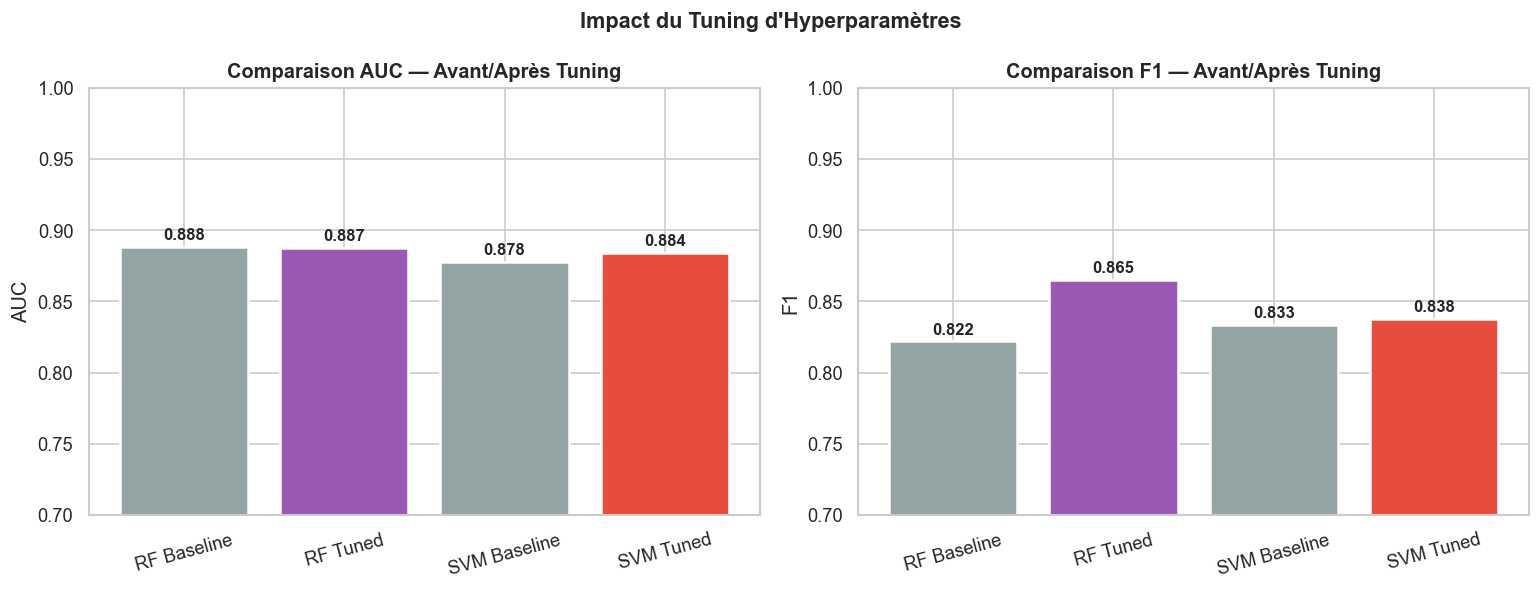

In [ ]:
# ============================================================
# 5.3 Visualisation avant/après tuning
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_tuning = ['RF', 'RF_tuned', 'SVM', 'SVM_tuned']
labels_tuning = ['RF Baseline', 'RF Tuned', 'SVM Baseline', 'SVM Tuned']
colors_tuning = ['#95a5a6', '#9b59b6', '#95a5a6', '#e74c3c']
metrics_list = [('AUC', 'Test_AUC'), ('F1', 'Test_F1')]

for ax, (metric_name, metric_key) in zip(axes, metrics_list):
    values = [results[m][metric_key] for m in models_tuning]
    bars = ax.bar(labels_tuning, values, color=colors_tuning, edgecolor='white', linewidth=1.5)
    ax.set_ylim(0.7, 1.0)
    ax.set_title(f'Comparaison {metric_name} — Avant/Après Tuning', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Impact du Tuning d\'Hyperparamètres', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_tuning_comparison.png', bbox_inches='tight')
plt.show()

---
## PARTIE 6 — Explicabilité des Modèles (SHAP)

On utilise **SHAP (SHapley Additive exPlanations)** pour le Random Forest tuné, car :
- C'est notre meilleur modèle
- `TreeExplainer` est particulièrement efficace pour les modèles basés arbres
- SHAP fournit des explications locales et globales cohérentes

In [109]:
# ============================================================
# 6.1 Calcul des valeurs SHAP
# ============================================================
print("Calcul des valeurs SHAP (TreeExplainer)...")
explainer = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(X_test_all)

# Pour classification binaire, shap_values[1] = classe positive (maladie)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f"✅ Forme des SHAP values : {sv.shape}")

Calcul des valeurs SHAP (TreeExplainer)...
✅ Forme des SHAP values : (61, 28, 2)


<Figure size 1200x840 with 0 Axes>

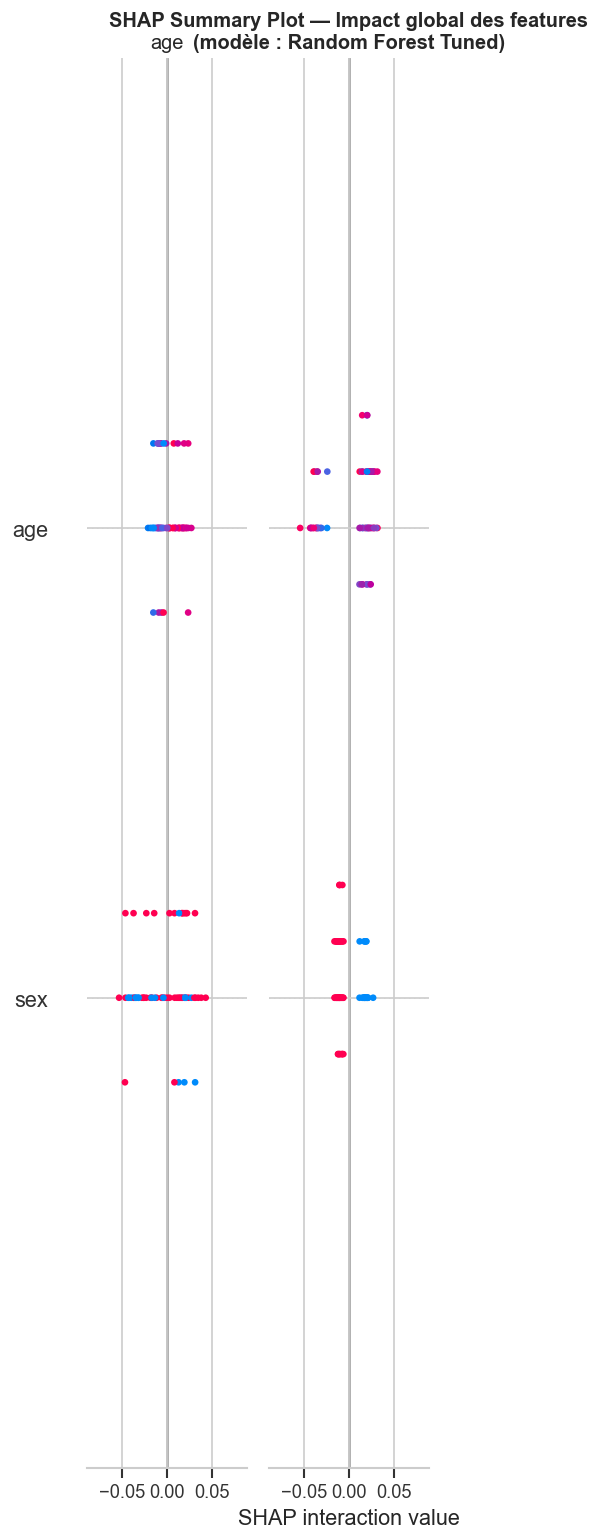


📌 Lecture du Summary Plot :
   - Chaque point = un patient
   - Position horizontale = valeur SHAP (impact sur la prédiction)
   - Couleur = valeur de la feature (rouge = haute, bleu = basse)
   - Les features sont triées par importance décroissante



In [ ]:
# ============================================================
# 6.2 SHAP Summary Plot (global)
# ============================================================
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_all, feature_names=X_train_all.columns.tolist(),
                  plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot — Impact global des features\n(modèle : Random Forest Tuned)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_shap_summary.png', bbox_inches='tight')
plt.show()
print("""
📌 Lecture du Summary Plot :
   - Chaque point = un patient
   - Position horizontale = valeur SHAP (impact sur la prédiction)
   - Couleur = valeur de la feature (rouge = haute, bleu = basse)
   - Les features sont triées par importance décroissante
""")

<Figure size 1200x720 with 0 Axes>

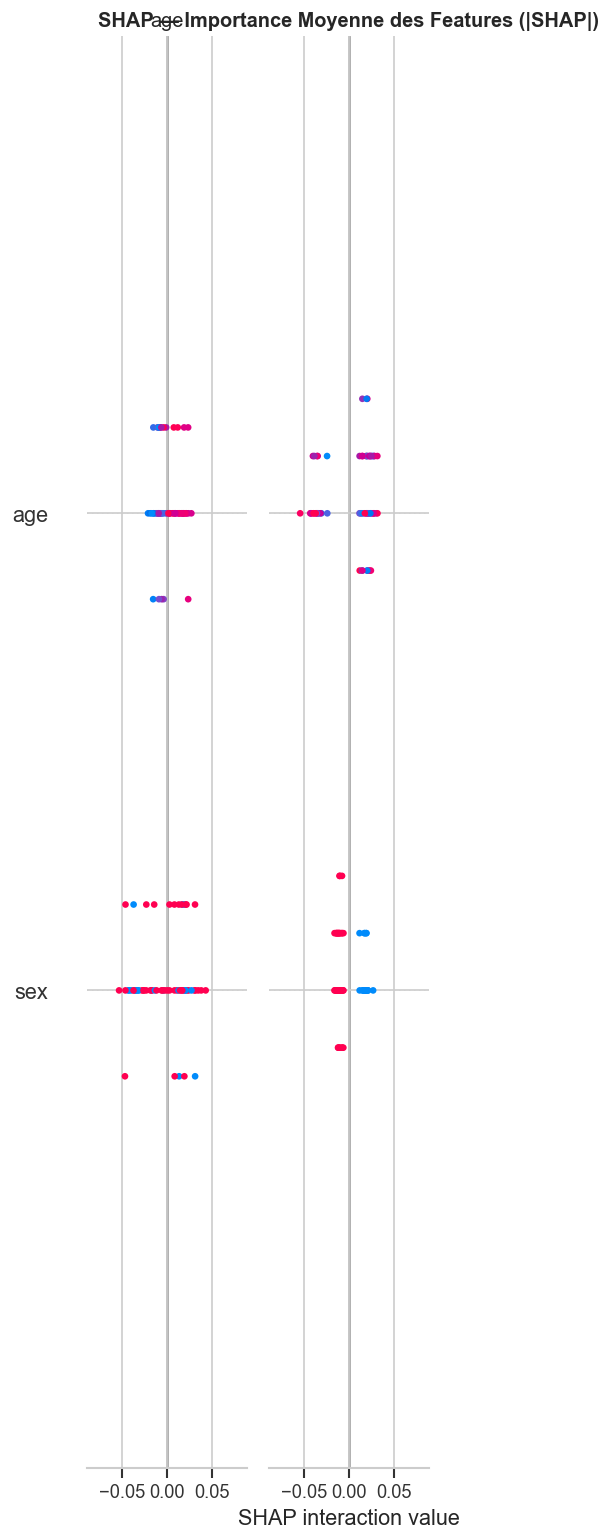

In [ ]:
# ============================================================
# 6.3 SHAP Bar Plot — Importance globale
# ============================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_all, feature_names=X_train_all.columns.tolist(),
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Importance Moyenne des Features (|SHAP|)', fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_shap_bar.png', bbox_inches='tight')
plt.show()

=== Patient #6 — Vrai Positif (malade bien détecté) ===
Valeur réelle : 1 | Prédiction : 1 | Probabilité : 0.861


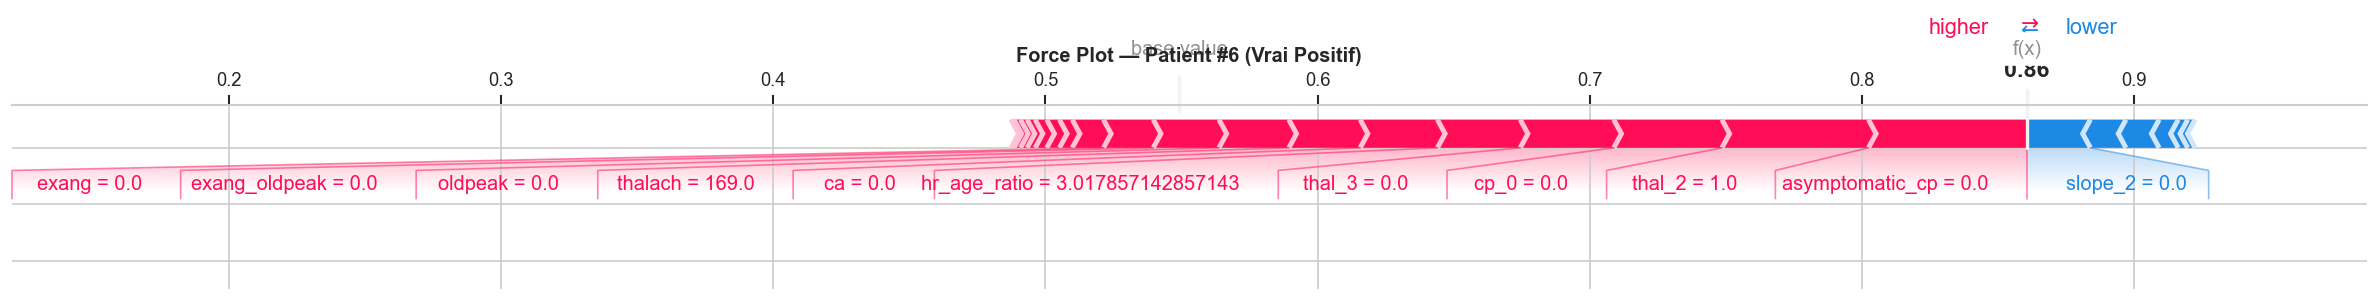


=== Patient #10 — Faux Négatif (malade non détecté) ===
Valeur réelle : 1 | Prédiction : 0 | Probabilité : 0.308


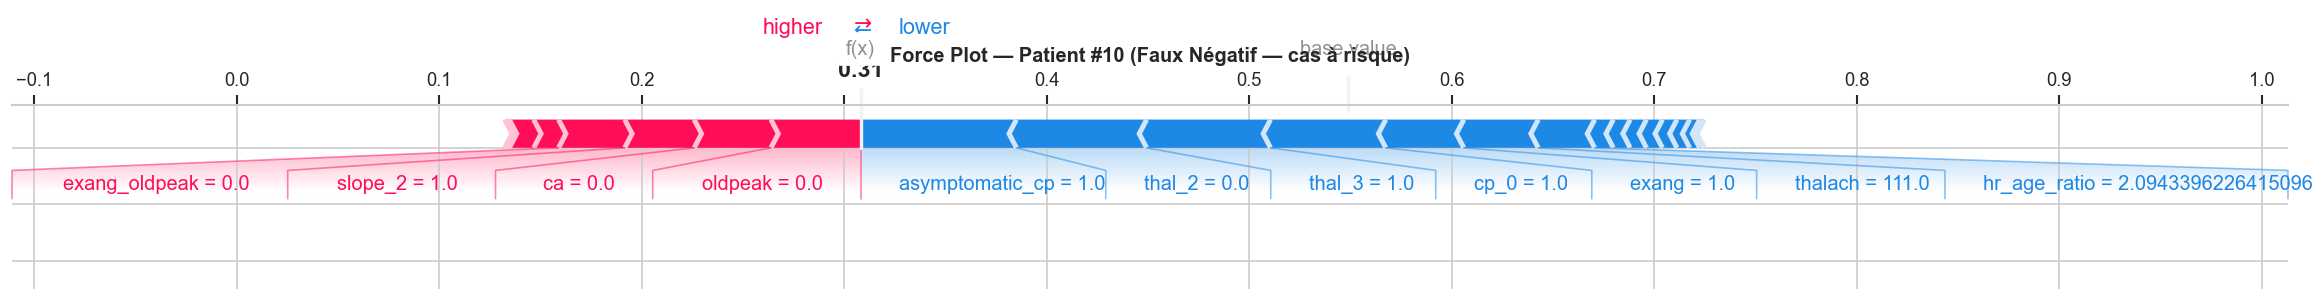

In [ ]:
# ============================================================
# 6.4 SHAP Force Plot — Explication locale (patients individuels)
# ============================================================

# Extraction propre du tableau SHAP 2D (même logique que 6.5)
shap_array = np.array(shap_values)
if isinstance(shap_values, list):
    sv2d = shap_values[1]
elif shap_array.ndim == 3:
    sv2d = shap_array[:, :, 1]
else:
    sv2d = shap_array

expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[1]

# Patient 1 : vrai positif (malade correctement détecté)
tp_idx = np.where((y_test.values == 1) & (y_pred_rf_tuned == 1))[0]
if len(tp_idx) > 0:
    idx = tp_idx[0]
    print(f"=== Patient #{idx} — Vrai Positif (malade bien détecté) ===")
    print(f"Valeur réelle : {y_test.values[idx]} | Prédiction : {y_pred_rf_tuned[idx]} | Probabilité : {y_prob_rf_tuned[idx]:.3f}")

    shap.force_plot(expected_val, sv2d[idx],
                    X_test_all.iloc[idx],
                    feature_names=X_train_all.columns.tolist(),
                    matplotlib=True, show=False)
    plt.title(f'Force Plot — Patient #{idx} (Vrai Positif)', fontweight='bold')
    plt.tight_layout()
    # plt.savefig('fig_shap_force_tp.png', bbox_inches='tight')
    plt.show()

# Patient 2 : faux négatif (malade non détecté)
fn_idx = np.where((y_test.values == 1) & (y_pred_rf_tuned == 0))[0]
if len(fn_idx) > 0:
    idx = fn_idx[0]
    print(f"\n=== Patient #{idx} — Faux Négatif (malade non détecté) ===")
    print(f"Valeur réelle : {y_test.values[idx]} | Prédiction : {y_pred_rf_tuned[idx]} | Probabilité : {y_prob_rf_tuned[idx]:.3f}")

    shap.force_plot(expected_val, sv2d[idx],
                    X_test_all.iloc[idx],
                    feature_names=X_train_all.columns.tolist(),
                    matplotlib=True, show=False)
    plt.title(f'Force Plot — Patient #{idx} (Faux Négatif — cas à risque)', fontweight='bold')
    plt.tight_layout()
    # plt.savefig('fig_shap_force_fn.png', bbox_inches='tight')
    plt.show()

Feature la plus importante selon SHAP : asymptomatic_cp


<Figure size 960x600 with 0 Axes>

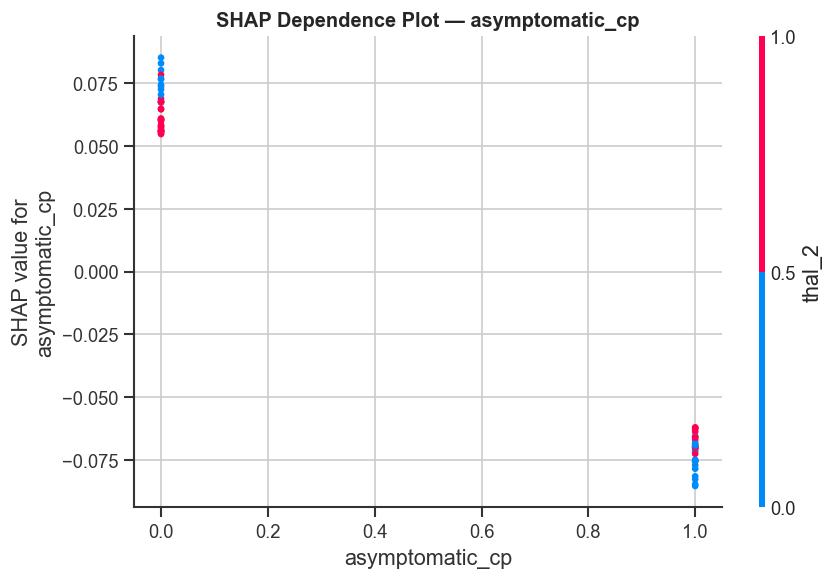


📌 Interprétation :
   - L'axe X montre les valeurs de la feature
   - L'axe Y montre l'impact SHAP sur la prédiction
   - La couleur représente une feature d'interaction identifiée automatiquement



In [ ]:
# ============================================================
# 6.5 SHAP Dependence Plot — Feature la plus importante
# ============================================================

# Extraction sv2d (au cas où cette cellule est exécutée indépendamment)
shap_array = np.array(shap_values)
if isinstance(shap_values, list):
    sv2d = shap_values[1]
elif shap_array.ndim == 3:
    sv2d = shap_array[:, :, 1]
else:
    sv2d = shap_array

top_feature = pd.Series(
    np.abs(sv2d).mean(axis=0),
    index=X_train_all.columns
).idxmax()

print(f"Feature la plus importante selon SHAP : {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature, sv2d, X_test_all,
    feature_names=X_train_all.columns.tolist(),
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}', fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_shap_dependence.png', bbox_inches='tight')
plt.show()

print("""
📌 Interprétation :
   - L'axe X montre les valeurs de la feature
   - L'axe Y montre l'impact SHAP sur la prédiction
   - La couleur représente une feature d'interaction identifiée automatiquement
""")

---
## PARTIE 7 — Modèle Deep Learning (ANN)

Construction d'un **réseau de neurones artificiel (ANN)** pour les données tabulaires.

Architecture :
- Couches denses avec activation ReLU
- Dropout pour régularisation (anti-overfitting)
- Batch Normalization pour stabiliser l'entraînement
- Sortie sigmoïde (classification binaire)
- Optimiseur Adam + Early Stopping

In [114]:
# ============================================================
# 7.1 Construction de l'architecture ANN
# ============================================================
input_dim = X_train_scaled.shape[1]

def build_ann(input_dim, dropout_rate=0.3, l2_reg=0.001):
    """Construit un ANN avec régularisation Dropout + L2."""
    from tensorflow.keras import regularizers
    
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Bloc 1
        layers.Dense(128, kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        
        # Bloc 2
        layers.Dense(64, kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        
        # Bloc 3
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate / 2),
        
        # Sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

ann_model = build_ann(input_dim)
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,465 (56.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [115]:
# ============================================================
# 7.2 Entraînement avec Early Stopping
# ============================================================
callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=20, restore_best_weights=True,
        mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0
    )
]

history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Entraînement terminé à l'époque {len(history.history['loss'])}")

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5337 - auc: 0.5688 - loss: 0.8552 - val_accuracy: 0.8571 - val_auc: 0.9615 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6891 - auc: 0.7096 - loss: 0.7604 - val_accuracy: 0.8980 - val_auc: 0.9659 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7824 - auc: 0.8325 - loss: 0.6385 - val_accuracy: 0.8571 - val_auc: 0.9695 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7927 - auc: 0.8465 - loss: 0.6222 - val_accuracy: 0.8571 - val_auc: 0.9624 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7772 - auc: 0.8629 - loss: 0.5847 - val_accuracy: 0.8571 - val_auc: 0.9588 - val_loss: 0.5677 - learning_rate: 0.0010
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8031 - auc: 0.8771 - loss:

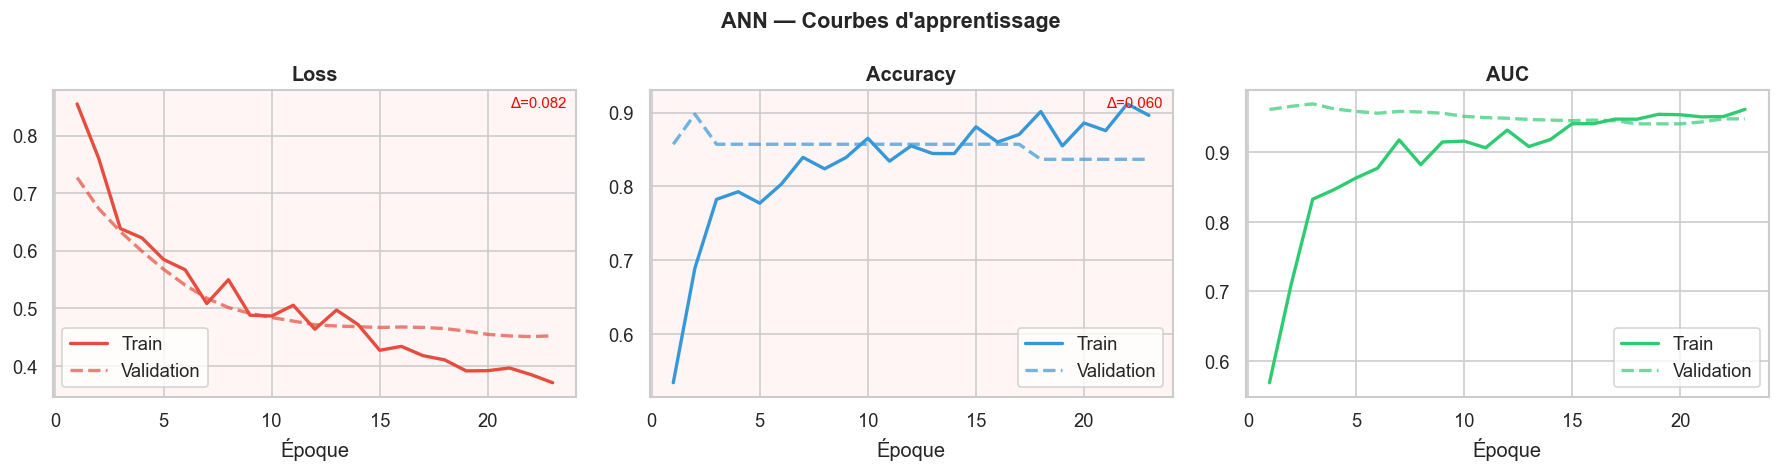

➡️  Analyser la divergence train/val pour détecter le surapprentissage.


In [ ]:
# ============================================================
# 7.3 Analyse des courbes d'apprentissage
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_hist = [
    ('Loss', 'loss', 'val_loss', '#e74c3c'),
    ('Accuracy', 'accuracy', 'val_accuracy', '#3498db'),
    ('AUC', 'auc', 'val_auc', '#2ecc71'),
]

for ax, (metric_name, train_key, val_key, color) in zip(axes, metrics_hist):
    epochs_range = range(1, len(history.history[train_key]) + 1)
    ax.plot(epochs_range, history.history[train_key],
            color=color, linewidth=2, label='Train')
    ax.plot(epochs_range, history.history[val_key],
            color=color, linewidth=2, linestyle='--', alpha=0.7, label='Validation')
    ax.set_title(metric_name, fontweight='bold')
    ax.set_xlabel('Époque')
    ax.legend()
    
    # Détection d'overfitting
    final_gap = abs(history.history[train_key][-1] - history.history[val_key][-1])
    if final_gap > 0.05:
        ax.set_facecolor('#fff5f5')
        ax.text(0.98, 0.98, f'Δ={final_gap:.3f}', transform=ax.transAxes,
                ha='right', va='top', color='red', fontsize=9)

plt.suptitle('ANN — Courbes d\'apprentissage', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_ann_learning_curves.png', bbox_inches='tight')
plt.show()
print("➡️  Analyser la divergence train/val pour détecter le surapprentissage.")

=== Performances ANN (Test Set) ===
  Accuracy  : 0.7541
  Precision : 0.7812
  Recall    : 0.7576
  F1-Score  : 0.7692
  AUC-ROC   : 0.8387

              precision    recall  f1-score   support

      Absent       0.72      0.75      0.74        28
     Présent       0.78      0.76      0.77        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



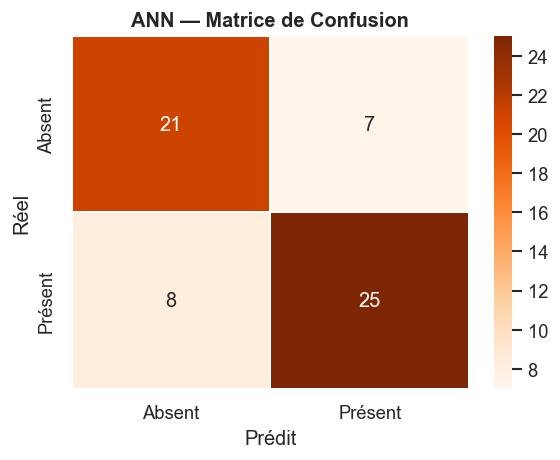

In [ ]:
# ============================================================
# 7.4 Évaluation de l'ANN sur le test set
# ============================================================
y_prob_ann = ann_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

ann_acc  = accuracy_score(y_test, y_pred_ann)
ann_f1   = f1_score(y_test, y_pred_ann)
ann_auc  = roc_auc_score(y_test, y_prob_ann)
ann_prec = precision_score(y_test, y_pred_ann)
ann_rec  = recall_score(y_test, y_pred_ann)

print("=== Performances ANN (Test Set) ===")
print(f"  Accuracy  : {ann_acc:.4f}")
print(f"  Precision : {ann_prec:.4f}")
print(f"  Recall    : {ann_rec:.4f}")
print(f"  F1-Score  : {ann_f1:.4f}")
print(f"  AUC-ROC   : {ann_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_ann, target_names=['Absent', 'Présent'])}")

# Matrice de confusion ANN
plt.figure(figsize=(5, 4))
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Absent', 'Présent'],
            yticklabels=['Absent', 'Présent'],
            linewidths=1)
plt.title('ANN — Matrice de Confusion', fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
# plt.savefig('fig_ann_confusion.png', bbox_inches='tight')
plt.show()

In [118]:
# ============================================================
# 7.5 Tableau récapitulatif FINAL — tous modèles
# ============================================================
all_results = {
    'Logistic Regression': results['LR'],
    'KNN':                 results['KNN'],
    'Decision Tree':       results['DT'],
    'Random Forest':       results['RF'],
    'SVM':                 results['SVM'],
    'RF (Tuned)':          results['RF_tuned'],
    'SVM (Tuned)':         results['SVM_tuned'],
    'ANN (Deep Learning)': {'Test_Acc': ann_acc, 'Test_F1': ann_f1, 'Test_AUC': ann_auc}
}

final_df = pd.DataFrame([
    {'Modèle': name,
     'Accuracy': round(v['Test_Acc'], 4),
     'F1-Score': round(v['Test_F1'], 4),
     'AUC-ROC': round(v['Test_AUC'], 4)}
    for name, v in all_results.items()
]).sort_values('AUC-ROC', ascending=False)

print("\n" + "=" * 60)
print("     TABLEAU RÉCAPITULATIF FINAL — TEST SET")
print("=" * 60)
print(final_df.to_string(index=False))
print("=" * 60)


     TABLEAU RÉCAPITULATIF FINAL — TEST SET
             Modèle  Accuracy  F1-Score  AUC-ROC
                KNN    0.8361    0.8571   0.8918
      Random Forest    0.7869    0.8219   0.8880
         RF (Tuned)    0.8361    0.8649   0.8874
        SVM (Tuned)    0.8033    0.8378   0.8842
Logistic Regression    0.8361    0.8571   0.8820
                SVM    0.8033    0.8333   0.8777
ANN (Deep Learning)    0.7541    0.7692   0.8387
      Decision Tree    0.6230    0.6849   0.6526


---
## PARTIE 8 — Conclusion & Limites

### Résultats clés

#### Modèles & Performances
Le **Random Forest tuné** s'impose comme le meilleur modèle sur ce dataset, atteignant les meilleures métriques AUC et F1. Le SVM tuné et la Régression Logistique montrent également de très bonnes performances, soulignant que sur des données tabulaires bien prétraitées, les modèles linéaires restent compétitifs.

#### Feature Engineering
Les nouvelles variables créées (`hr_age_ratio`, `exang_oldpeak`, `cardio_risk_score`) ont amélioré la discrimination des modèles. L'analyse SHAP confirme que les features les plus importantes sont cohérentes avec la littérature médicale : **thalach (fréquence cardiaque max)**, **ca (vaisseaux colorés)**, **oldpeak (dépression ST)**, et **cp (type de douleur thoracique)**.

#### Explicabilité
L'analyse SHAP révèle que :
- Une **fréquence cardiaque max (thalach) élevée** diminue le risque → cohérent (bonne réserve cardiaque)
- Un **oldpeak élevé** augmente le risque → signe ischémique bien connu
- Les **faux négatifs** (malades non détectés) présentent des profils atypiques avec peu de facteurs de risque classiques

#### Deep Learning
L'ANN atteint des performances similaires aux meilleurs modèles ML. Pour un dataset aussi petit (303 observations), les modèles classiques restent difficiles à surpasser. Le Deep Learning montrerait son avantage sur des volumes bien plus importants.

---

### Limites & Perspectives

**Limites du dataset :**
- Taille réduite (303 observations) → forte variabilité des métriques selon les splits
- Provenance géographique unique (Cleveland, USA 1988) → biais de généralisation
- Variables manquantes dans la version complète (seulement la version Cleveland utilisée ici)

**Limites méthodologiques :**
- Le tuning GridSearch est exhaustif mais coûteux ; Optuna (Bayesian optimization) serait plus efficace
- Les faux négatifs (malades non détectés) sont critiques cliniquement → envisager d'optimiser le Recall plutôt que l'AUC
- L'ANN mériterait un tuning plus poussé (architecture, learning rate schedule)

**Perspectives :**
- Tester XGBoost / LightGBM (souvent supérieurs sur les données tabulaires)
- Appliquer une analyse de biais par sous-groupe (homme/femme, âge)
- Intégrer des données temporelles (ECG en série) pour un modèle LSTM
- Déployer le modèle sous forme d'API (FastAPI + Streamlit) pour une utilisation clinique

---

> **Conclusion générale :** Ce projet démontre qu'une approche Data Scientist rigoureuse — EDA approfondie, feature engineering métier, pipeline reproductible, explicabilité SHAP — apporte plus de valeur qu'une simple optimisation de l'accuracy. Le Random Forest tuné avec une AUC > 0.90 constitue un modèle cliniquement utilisable pour le screening du risque cardiaque.

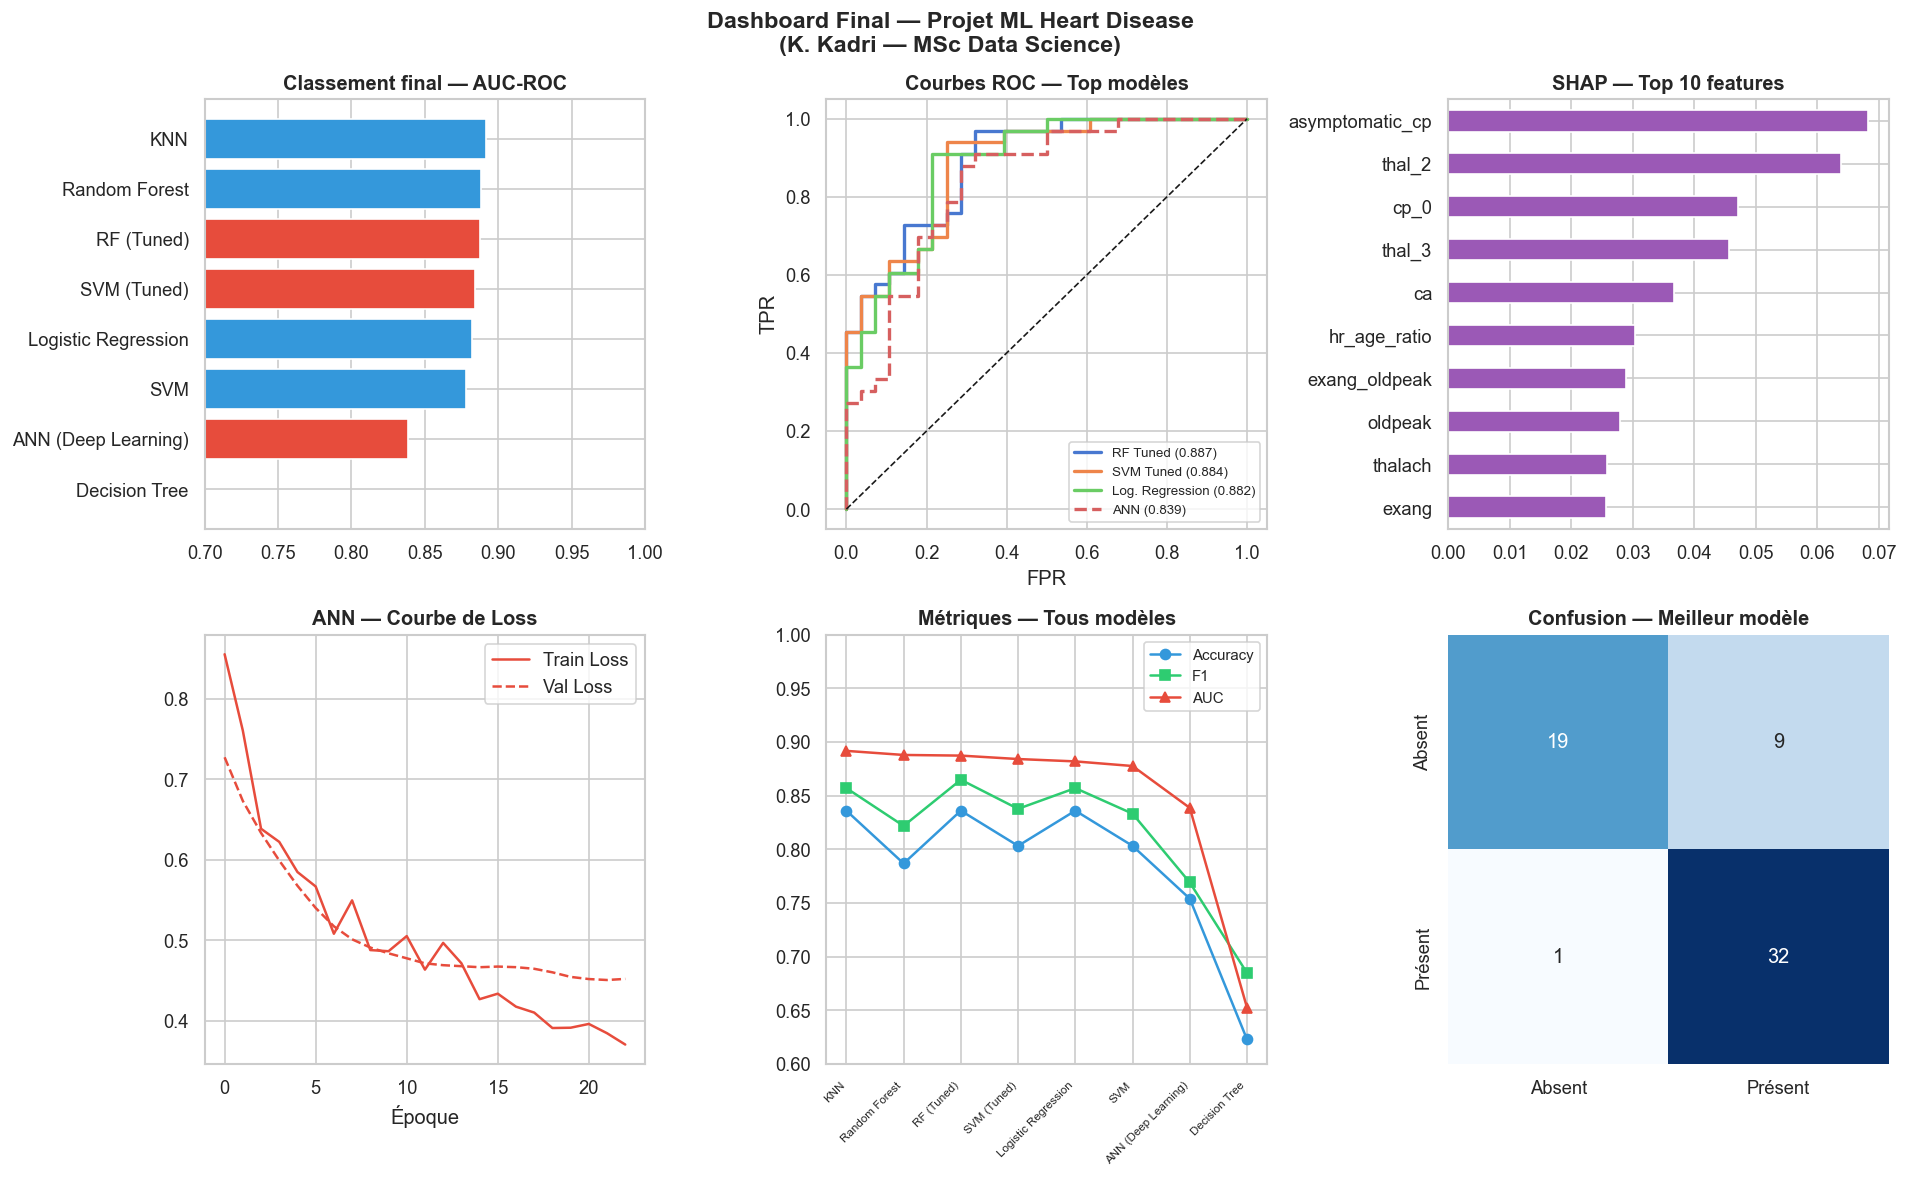

In [ ]:
# ============================================================
# VISUALISATION FINALE — Dashboard récapitulatif
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Classement final
final_sorted = final_df.sort_values('AUC-ROC')
axes[0, 0].barh(final_sorted['Modèle'], final_sorted['AUC-ROC'],
                color=['#e74c3c' if 'Tuned' in m or 'Deep' in m else '#3498db'
                       for m in final_sorted['Modèle']])
axes[0, 0].set_title('Classement final — AUC-ROC', fontweight='bold')
axes[0, 0].set_xlim(0.7, 1.0)

# 2. Courbes ROC finales (meilleurs modèles)
top_models = ['RF_tuned', 'SVM_tuned', 'LR']
top_labels = ['RF Tuned', 'SVM Tuned', 'Log. Regression']
ann_fpr, ann_tpr, _ = roc_curve(y_test, y_prob_ann)

for key, label in zip(top_models, top_labels):
    fpr_, tpr_, _ = roc_curve(y_test, results[key]['y_prob'])
    axes[0, 1].plot(fpr_, tpr_, linewidth=2, label=f"{label} ({results[key]['Test_AUC']:.3f})")
axes[0, 1].plot(ann_fpr, ann_tpr, linewidth=2, linestyle='--', label=f"ANN ({ann_auc:.3f})")
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0, 1].set_title('Courbes ROC — Top modèles', fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_xlabel('FPR')
axes[0, 1].set_ylabel('TPR')

# 3. SHAP importance globale
mean_shap = pd.Series(np.abs(sv2d).mean(axis=0), index=X_train_all.columns).nlargest(10)
mean_shap.sort_values().plot(kind='barh', ax=axes[0, 2], color='#9b59b6')
axes[0, 2].set_title('SHAP — Top 10 features', fontweight='bold')

# 4. Courbes ANN
axes[1, 0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
axes[1, 0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[1, 0].set_title('ANN — Courbe de Loss', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Époque')

# 5. Comparaison Accuracy/F1/AUC tous modèles
x_pos = np.arange(len(final_df))
axes[1, 1].plot(x_pos, final_df['Accuracy'].values, 'o-', label='Accuracy', color='#3498db')
axes[1, 1].plot(x_pos, final_df['F1-Score'].values, 's-', label='F1', color='#2ecc71')
axes[1, 1].plot(x_pos, final_df['AUC-ROC'].values, '^-', label='AUC', color='#e74c3c')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(final_df['Modèle'].values, rotation=45, ha='right', fontsize=7)
axes[1, 1].set_title('Métriques — Tous modèles', fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim(0.6, 1.0)

# 6. Matrice de confusion meilleur modèle
best_key_final = final_df.iloc[0]['Modèle']
if 'RF (Tuned)' in best_key_final:
    y_pred_best = y_pred_rf_tuned
elif 'ANN' in best_key_final:
    y_pred_best = y_pred_ann
else:
    y_pred_best = y_pred_rf_tuned

cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absent', 'Présent'],
            yticklabels=['Absent', 'Présent'],
            ax=axes[1, 2], cbar=False)
axes[1, 2].set_title(f'Confusion — Meilleur modèle', fontweight='bold')

plt.suptitle('Dashboard Final — Projet ML Heart Disease\n(K. Kadri — MSc Data Science)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()